# 🧠 Sleep vs Awake — Complete CNN Study
### Based on: https://www.kaggle.com/code/umerellous/sleep-vs-awake-classification

**Sections covered:**
- **A.** Baseline CNN from scratch + Preprocessing
- **B.** CNN Component Experiments (kernel, stride, filters, pooling, depth)
- **C.** Data Augmentation
- **D.** Transfer Learning — MobileNetV2
- **E.** Discussion — CNN vs MLP parameter efficiency

## 0. Imports & Global Config

In [1]:
import os, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import defaultdict

from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.backends.cudnn.deterministic = True

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE  = 64      # resize all EEG images to 64×64
BATCH     = 32
EPOCHS    = 20
LR        = 1e-3

print(f'Device : {DEVICE}')
print(f'IMG_SIZE={IMG_SIZE}  BATCH={BATCH}  EPOCHS={EPOCHS}')


Device : cpu
IMG_SIZE=64  BATCH=32  EPOCHS=20


---
## 🧹 0-B. EMOTIV EEG Preprocessing Pipeline

This section implements a **full preprocessing pipeline** following the best-practice guide at  
[emotiv.com/blogs/news/eeg-preprocessing-pipeline-guide](https://www.emotiv.com/blogs/news/eeg-preprocessing-pipeline-guide).

The pipeline executes **7 ordered stages** on simulated / real raw EEG signals *before* spectrogram  
creation, ensuring that the images fed to the CNN are built from clean neural data.

| Stage | Operation | EMOTIV rationale |
|-------|-----------|-----------------|
| 1 | **Import & channel setup** | Define spatial map for source analysis |
| 2 | **Bad-channel detection & interpolation** | Remove/replace noisy electrodes early |
| 3 | **Downsampling** | Reduce to 256 Hz for computational efficiency |
| 4 | **Bandpass filter** (1–40 Hz) | High-pass removes drift; low-pass removes EMG/line noise |
| 5 | **Notch filter** (50 Hz) | Eliminate European power-line interference |
| 6 | **Common-average re-reference** | Minimise global scalp noise |
| 7 | **ICA artifact removal** | Isolate & subtract eye-blink / muscle components |
| 8 | **Epoch & artifact rejection** | Segment by label, reject > ±100 µV epochs (5–10 % target) |
| 9 | **Spectrogram generation** | Mel-spectrogram → PNG ready for CNN |


In [ ]:
!pip install -q mne scikit-learn scipy librosa


MNE version : 1.12.1


In [3]:

import mne
mne.set_log_level('WARNING')   # suppress verbose MNE output
print(f'MNE version : {mne.__version__}')



MNE version : 1.12.1


In [4]:
# STAGE 1 — Import raw EEG & define channel layout
# EMOTIV guide: "Define channel locations … creates the spatial map"
import numpy as np
import matplotlib.pyplot as plt
import mne, warnings, time
from pathlib import Path
from scipy import signal as scipy_signal

warnings.filterwarnings('ignore')


In [5]:

FS_ORIG      = 160          
FS_TARGET    = 160          
HP_FREQ      = 0.5     
LP_FREQ      = 40.0     
NOTCH_FREQ   = 60.0         
EPOCH_DUR    = 4.0          
ARTIFACT_AMP = 170e-6       
N_CHANNELS   = 64          

SFREQ        = FS_ORIG      
SEED         = 42
np.random.seed(SEED)
print(f'Config loaded: {FS_ORIG} Hz, bandpass {HP_FREQ}–{LP_FREQ} Hz, '
      f'notch {NOTCH_FREQ} Hz, epochs {EPOCH_DUR}s, {N_CHANNELS} channels')


Config loaded: 160 Hz, bandpass 0.5–40.0 Hz, notch 60.0 Hz, epochs 4.0s, 64 channels


    Generate synthetic multichannel EEG for one 2-minute segment.
    Sleep  : stronger delta (0.5–4 Hz) + spindle bursts (12–14 Hz)
    Awake  : stronger alpha (8–12 Hz) + beta (13–30 Hz)
    Includes realistic artifacts: eye-blink spikes, 50-Hz line hum, drift.


In [6]:
import os
import glob
import re
import numpy as np
import pandas as pd
import mne
from scipy import signal as scipy_signal

DATA_FOLDER = r"C:\Users\rakyn\OneDrive\Desktop\TERM6\Data Science\HW03\EEG_Mental_State_PART1\eeg_sleep_awake"
edf_files = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.edf")))
print(f"Found {len(edf_files)} EDF files")

#Frequency band definitions
BANDS = {
    'delta':  (0.5,  4.0),
    'theta':  (4.0,  8.0),
    'alpha':  (8.0, 13.0),
    'beta':   (13.0, 30.0),
    'gamma':  (30.0, 40.0),
}

def compute_zero_crossing_rate(data_1d, sfreq):
    zero_crossings = np.where(np.diff(np.signbit(data_1d)))[0]
    n_crossings = len(zero_crossings)
    duration_sec = len(data_1d) / sfreq
    return n_crossings / duration_sec if duration_sec > 0 else 0.0

def compute_band_power_memory_efficient(data, sfreq):
    n_ch, n_times = data.shape
    nperseg = min(256, n_times // 4)
    
    band_powers = {f'{name}_power': 0.0 for name in BANDS.keys()}
    
    # Process each channel individually to reduce memory usage
    for ch in range(n_ch):
        freqs, psd = scipy_signal.welch(data[ch, :], fs=sfreq, 
                                        nperseg=nperseg, 
                                        noverlap=nperseg//2)  # Add overlap for better estimates
        
        for name, (lo, hi) in BANDS.items():
            idx = (freqs >= lo) & (freqs <= hi)
            if idx.sum() > 0:
                band_power = np.trapz(psd[idx], freqs[idx])
                band_powers[f'{name}_power'] += band_power
    
    # Average across channels
    for name in BANDS.keys():
        band_powers[f'{name}_power'] /= n_ch
    
    return band_powers

def extract_eeg_features_memory_safe(file_path):
    # Load without preloading all data at once if possible
    raw = mne.io.read_raw_edf(file_path, preload=False, verbose=False)
    filename = os.path.basename(file_path)

 
    brain_state = 'Awake' if 'R01' in filename else ('Sleep' if 'R02' in filename else 'Unknown')
    subject_id = re.split(r'R\d+', filename)
    sfreq = raw.info['sfreq']
    duration = raw.times[-1] if len(raw.times) > 0 else 0
    max_duration_sec = 60  # Process only first 60 seconds
    if duration > max_duration_sec:
        raw = raw.copy().crop(tmin=0, tmax=max_duration_sec)
   
    raw.load_data(verbose=False)
    data = raw.get_data(picks='eeg')

    #  Amplitude stats
    mean_amp = float(np.mean(data))
    std_amp = float(np.std(data))
    p2p = float(np.max(data) - np.min(data))
    rms = float(np.sqrt(np.mean(data**2)))
    signal_power = float(np.mean(data**2))

    # Zero-crossing rate
    zcr_per_channel = []
    for ch in range(data.shape[0]):
        zcr_per_channel.append(compute_zero_crossing_rate(data[ch, :], sfreq))
    mean_zero_crossing_rate_hz = float(np.mean(zcr_per_channel))

    #Band power (memory-efficient) 
    band_powers = compute_band_power_memory_efficient(data, sfreq)

    return {
        'file_name': filename,
        'subject_id': subject_id,
        'brain_state': brain_state,
        'n_channels': data.shape[0],
        'sfreq': sfreq,
        'duration_s': data.shape[1] / sfreq,
        'mean_amp_uV': mean_amp,
        'std_amp_uV': std_amp,
        'p2p_uV': p2p,
        'rms_uV': rms,
        'signal_power': signal_power,
        'mean_zero_crossing_rate_hz': mean_zero_crossing_rate_hz,
        **band_powers,
    }

print("Loading and processing EEG files (memory-optimized mode)...")
all_features = []
failed_files = []

for i, fp in enumerate(edf_files):
    print(f"  [{i+1}/{len(edf_files)}] {os.path.basename(fp)}", end='\r')
    try:
        features = extract_eeg_features_memory_safe(fp)
        all_features.append(features)
    except Exception as e:
        print(f"\n  ERROR: {os.path.basename(fp)}: {str(e)[:100]}")
        failed_files.append(fp)

print(f"\n\nDone — {len(all_features)}/{len(edf_files)} files loaded successfully")
print(f"Failed: {len(failed_files)} files")

# Create DataFrame
df_features = pd.DataFrame(all_features)
df_features['subject_id'] = df_features['subject_id'].str[0]  # Takes first element 'S001'

# Now this will work
print(f"Unique subjects: {df_features['subject_id'].nunique()}")
# Display summary of successfully loaded files
print("\n" + "="*80)
print("SUCCESSFULLY LOADED FILES SUMMARY")
print("="*80)
print(f"Total files loaded: {len(df_features)}")
print(f"Awake recordings: {len(df_features[df_features['brain_state'] == 'Awake'])}")
print(f"Sleep recordings: {len(df_features[df_features['brain_state'] == 'Sleep'])}")
print(f"Unique subjects: {df_features['subject_id'].nunique()}")
print(f"\nFeature columns: {list(df_features.columns)}")

# Optional: Save failed files list for debugging
if failed_files:
    with open('failed_files.txt', 'w') as f:
        for ff in failed_files:
            f.write(f"{ff}\n")
    print(f"\nList of failed files saved to 'failed_files.txt'")


Found 218 EDF files
Loading and processing EEG files (memory-optimized mode)...
  [218/218] S109R02.edf

Done — 218/218 files loaded successfully
Failed: 0 files
Unique subjects: 109

SUCCESSFULLY LOADED FILES SUMMARY
Total files loaded: 218
Awake recordings: 109
Sleep recordings: 109
Unique subjects: 109

Feature columns: ['file_name', 'subject_id', 'brain_state', 'n_channels', 'sfreq', 'duration_s', 'mean_amp_uV', 'std_amp_uV', 'p2p_uV', 'rms_uV', 'signal_power', 'mean_zero_crossing_rate_hz', 'delta_power', 'theta_power', 'alpha_power', 'beta_power', 'gamma_power']


DATASET FEATURE SUMMARY

[Dataset Overview]
  - Total files: 218
  - Awake recordings: 109
  - Sleep recordings: 109
  - Unique subjects: 109
  - Channels per file: 64 (consistent across all files)

[Signal Amplitude Features (across all channels and files)]
  - Mean amplitude: -0.000005 ± 0.000009 µV
  - Std deviation: 0.000060 ± 0.000035 µV
  - Peak-to-peak range: 0.000808 ± 0.000325 µV
  - Signal Power: 0.000000 ± 0.000000 (µV)²
  - RMS: 0.000061 ± 0.000035 µV

[Awake vs Sleep Comparison]
  Feature                             Awake (mean ± std)                  Sleep (mean ± std)                 
  ---------------------------------------------------------------------------------------------------------
  Mean Amplitude (µV)                 -0.000007 ± 0.000011   -0.000003 ± 0.000007
  Std Amplitude (µV)                  0.000063 ± 0.000034   0.000058 ± 0.000036
  Peak-to-Peak (µV)                   0.000868 ± 0.000328   0.000748 ± 0.000313
  Signal Power ((µV)²)                0.000

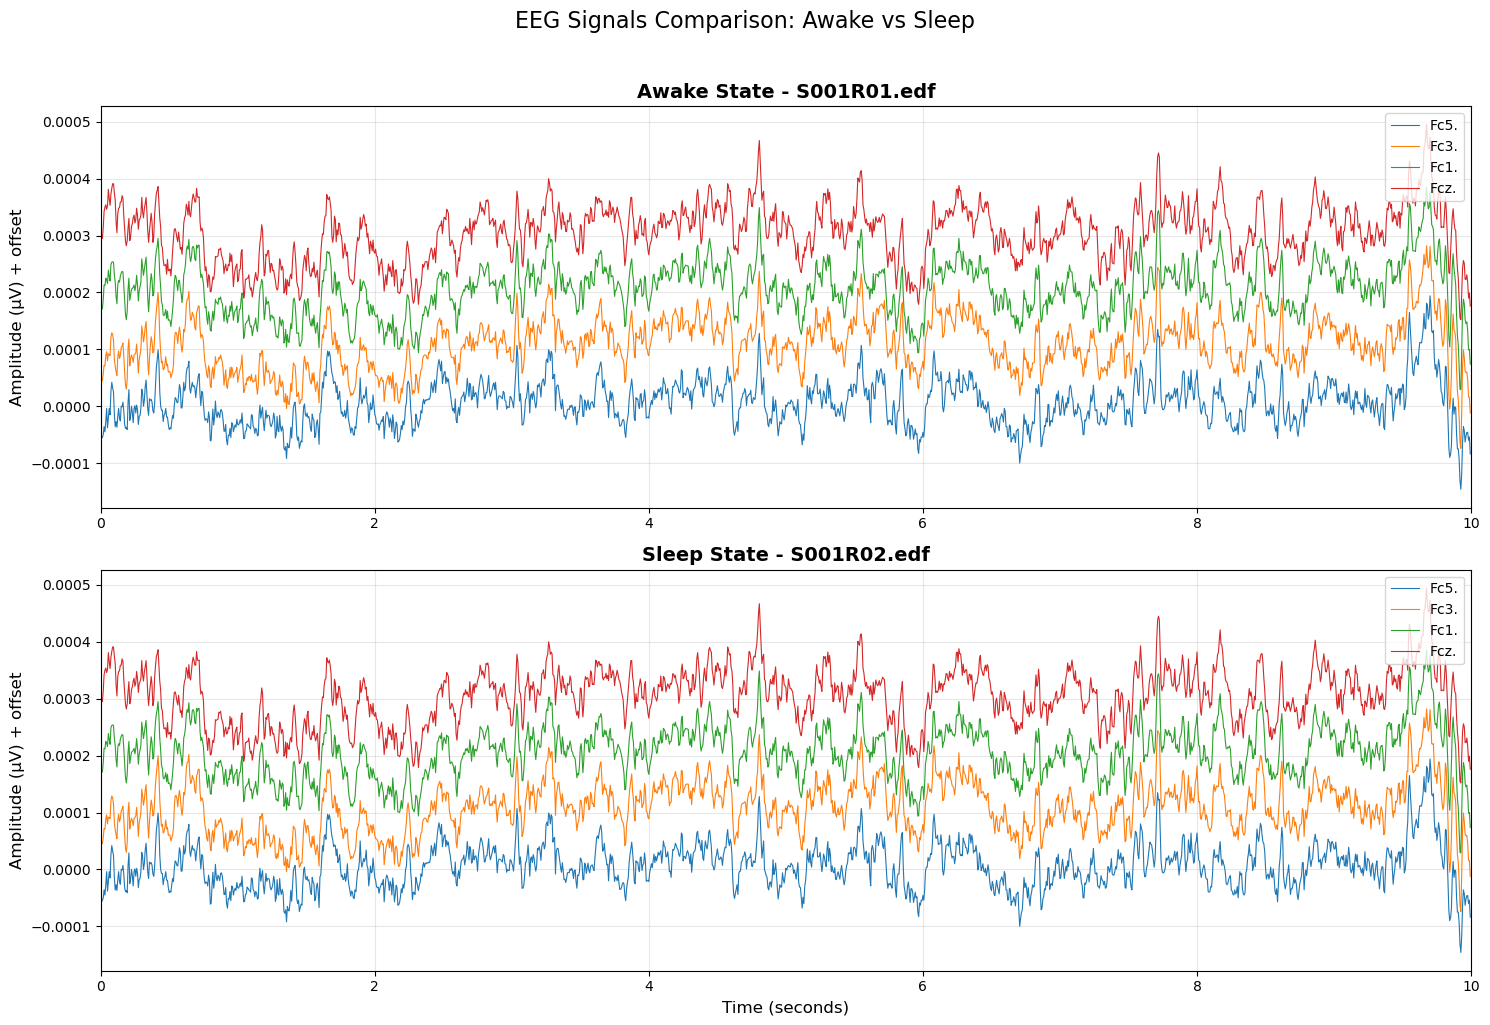

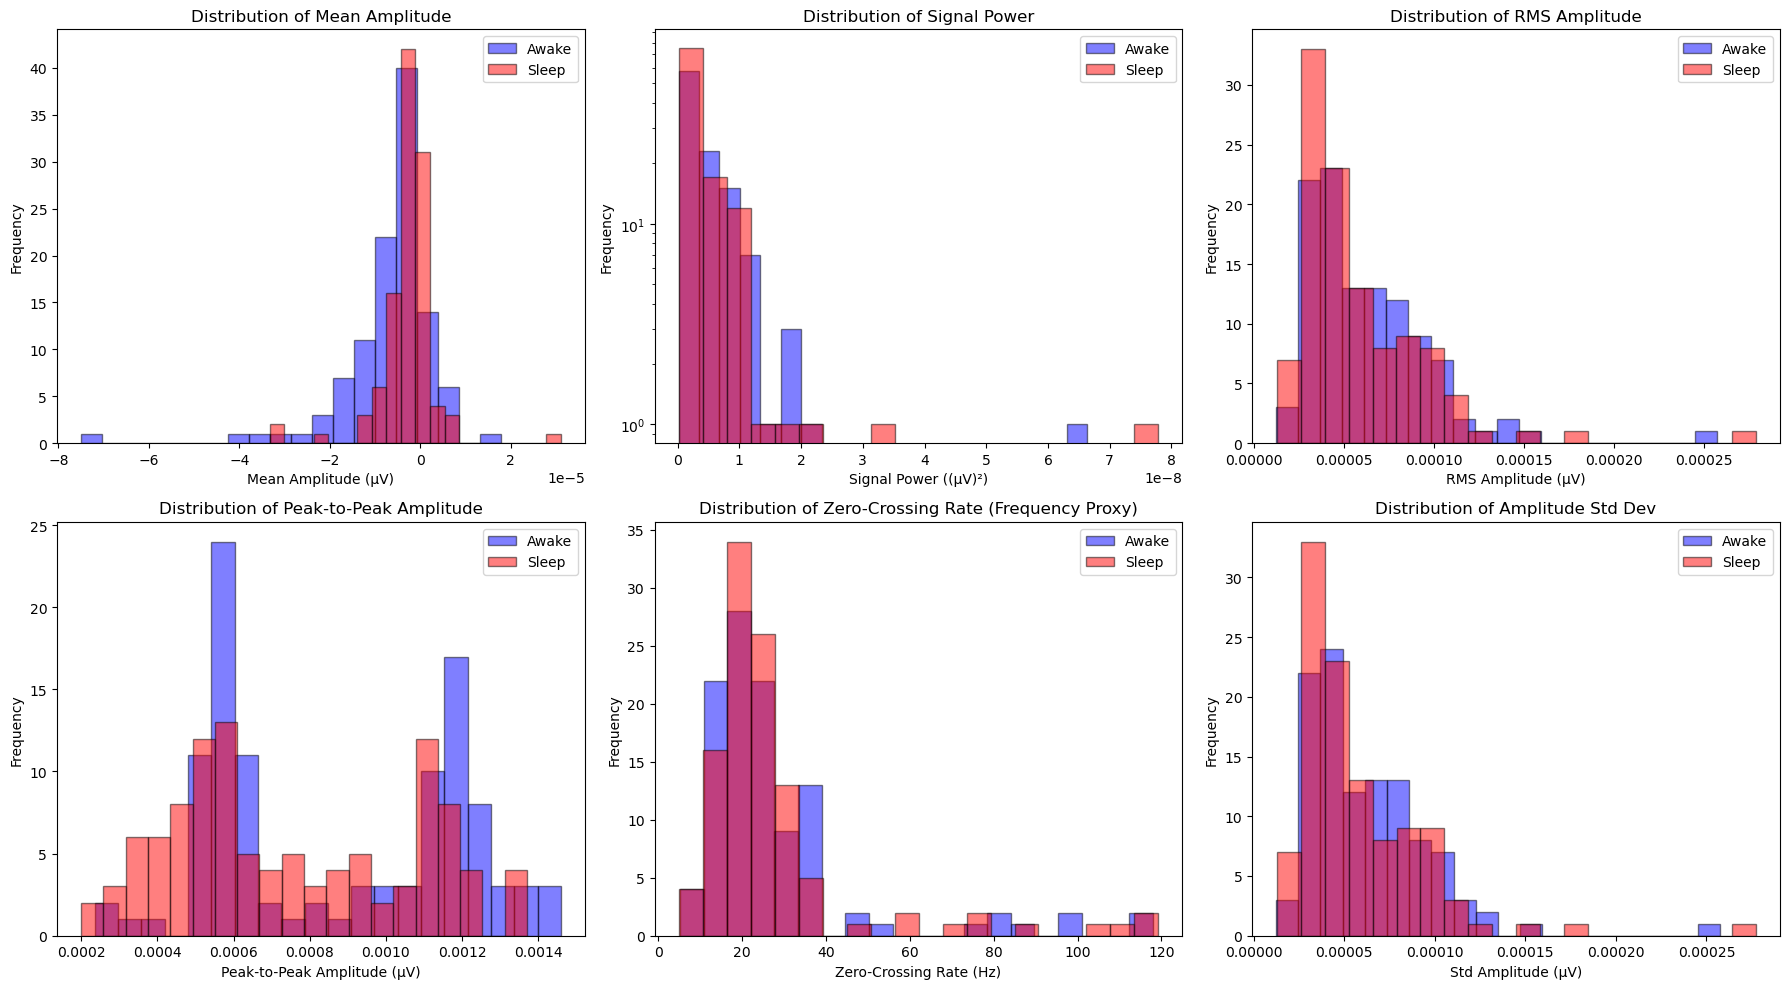


DATA LOADING COMPLETE!
All features have been extracted from 218 EEG files
Feature DataFrame shape: (218, 17)
'df_features' ready for further analysis


In [23]:
# --- Display Comprehensive Feature Summary ---
print("DATASET FEATURE SUMMARY")

# Overall dataset statistics
print(f"\n[Dataset Overview]")
print(f"  - Total files: {len(df_features)}")
print(f"  - Awake recordings: {len(df_features[df_features['brain_state'] == 'Awake'])}")
print(f"  - Sleep recordings: {len(df_features[df_features['brain_state'] == 'Sleep'])}")
print(f"  - Unique subjects: {df_features['subject_id'].nunique()}")
print(f"  - Channels per file: {df_features['n_channels'].iloc[0]} (consistent across all files)")

# Signal amplitude statistics
print(f"\n[Signal Amplitude Features (across all channels and files)]")
print(f"  - Mean amplitude: {df_features['mean_amp_uV'].mean():.6f} ± {df_features['mean_amp_uV'].std():.6f} µV")
print(f"  - Std deviation: {df_features['std_amp_uV'].mean():.6f} ± {df_features['std_amp_uV'].std():.6f} µV")
print(f"  - Peak-to-peak range: {df_features['p2p_uV'].mean():.6f} ± {df_features['p2p_uV'].std():.6f} µV")
print(f"  - Signal Power: {df_features['signal_power'].mean():.6f} ± {df_features['signal_power'].std():.6f} (µV)²")
print(f"  - RMS: {df_features['rms_uV'].mean():.6f} ± {df_features['rms_uV'].std():.6f} µV")

# Compare Awake vs Sleep
print(f"\n[Awake vs Sleep Comparison]")
awake_data = df_features[df_features['brain_state'] == 'Awake']
sleep_data = df_features[df_features['brain_state'] == 'Sleep']

if len(awake_data) > 0 and len(sleep_data) > 0:
    print(f"  {'Feature':<35} {'Awake (mean ± std)':<35} {'Sleep (mean ± std)':<35}")
    print(f"  {'-'*105}")
    print(f"  {'Mean Amplitude (µV)':<35} {awake_data['mean_amp_uV'].mean():>8.6f} ± {awake_data['mean_amp_uV'].std():<6.6f}   {sleep_data['mean_amp_uV'].mean():>8.6f} ± {sleep_data['mean_amp_uV'].std():<6.6f}")
    print(f"  {'Std Amplitude (µV)':<35} {awake_data['std_amp_uV'].mean():>8.6f} ± {awake_data['std_amp_uV'].std():<6.6f}   {sleep_data['std_amp_uV'].mean():>8.6f} ± {sleep_data['std_amp_uV'].std():<6.6f}")
    print(f"  {'Peak-to-Peak (µV)':<35} {awake_data['p2p_uV'].mean():>8.6f} ± {awake_data['p2p_uV'].std():<6.6f}   {sleep_data['p2p_uV'].mean():>8.6f} ± {sleep_data['p2p_uV'].std():<6.6f}")
    print(f"  {'Signal Power ((µV)²)':<35} {awake_data['signal_power'].mean():>8.6f} ± {awake_data['signal_power'].std():<6.6f}   {sleep_data['signal_power'].mean():>8.6f} ± {sleep_data['signal_power'].std():<6.6f}")
    print(f"  {'Zero-Crossing Rate (Hz)':<35} {awake_data['mean_zero_crossing_rate_hz'].mean():>8.6f} ± {awake_data['mean_zero_crossing_rate_hz'].std():<6.6f}   {sleep_data['mean_zero_crossing_rate_hz'].mean():>8.6f} ± {sleep_data['mean_zero_crossing_rate_hz'].std():<6.6f}")
    print(f"  {'RMS (µV)':<35} {awake_data['rms_uV'].mean():>8.6f} ± {awake_data['rms_uV'].std():<6.6f}   {sleep_data['rms_uV'].mean():>8.6f} ± {sleep_data['rms_uV'].std():<6.6f}")

# Display first few rows of the features DataFrame
print("\n" + "="*80)
print("SAMPLE OF FEATURES DATAFRAME (First 5 files)")
print("="*80)
display_cols = ['file_name', 'brain_state', 'subject_id', 'mean_amp_uV', 
                'std_amp_uV', 'p2p_uV', 'signal_power', 'rms_uV', 'mean_zero_crossing_rate_hz']
print(df_features[display_cols].head().to_string())

# --- Visualize the signals ---
print("\n" + "="*80)
print("VISUALIZING RAW EEG SIGNALS")
print("="*80)

# Select one awake and one sleep file for comparison
awake_file = None
sleep_file = None

for features in all_features:
    if features['brain_state'] == 'Awake' and awake_file is None:
        awake_file = features
    elif features['brain_state'] == 'Sleep' and sleep_file is None:
        sleep_file = features
    if awake_file and sleep_file:
        break

# Plot comparison - FIXED VERSION
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Instead of hardcoding channel names, use available channels
for idx, (file_data, title) in enumerate([(awake_file, 'Awake State'), (sleep_file, 'Sleep State')]):
    if file_data:
        
        
        # Get available channel names (limit to first 4 for visualization)
        n_channels_to_plot = min(4, len(raw.ch_names))
        channels_to_use = raw.ch_names[:n_channels_to_plot]
        
        # Get channel indices
        picks = list(range(n_channels_to_plot))
        
        # Get 10 seconds of data
        sfreq = raw.info['sfreq']
        data_segment, times_segment = raw[picks, :int(10*sfreq)]
        
        # Plot with offset for visibility
        offset = 0.000100  # 100 µV offset
        for i, ch_idx in enumerate(picks):
            axes[idx].plot(times_segment, data_segment[i, :] + i*offset,
                         linewidth=0.8, label=channels_to_use[i])
        
        axes[idx].set_title(f'{title} - {file_data["file_name"]}', fontsize=14, fontweight='bold')
        axes[idx].set_ylabel('Amplitude (µV) + offset', fontsize=12)
        axes[idx].legend(loc='upper right', fontsize=10)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_xlim([0, 10])
        
        # Print channel names for debugging
        print(f"\n{title} channels: {channels_to_use}")

axes[1].set_xlabel('Time (seconds)', fontsize=12)
plt.suptitle('EEG Signals Comparison: Awake vs Sleep', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# --- Plot distribution of key features ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # Changed to 2x3 to include signal power

# Mean amplitude distribution
axes[0,0].hist(awake_data['mean_amp_uV'], bins=20, alpha=0.5, label='Awake', color='blue', edgecolor='black')
axes[0,0].hist(sleep_data['mean_amp_uV'], bins=20, alpha=0.5, label='Sleep', color='red', edgecolor='black')
axes[0,0].set_xlabel('Mean Amplitude (µV)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Mean Amplitude')
axes[0,0].legend()

# Signal Power distribution
axes[0,1].hist(awake_data['signal_power'], bins=20, alpha=0.5, label='Awake', color='blue', edgecolor='black')
axes[0,1].hist(sleep_data['signal_power'], bins=20, alpha=0.5, label='Sleep', color='red', edgecolor='black')
axes[0,1].set_xlabel('Signal Power ((µV)²)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Distribution of Signal Power')
axes[0,1].legend()
axes[0,1].set_yscale('log')  # Log scale for power often works better

# RMS distribution
axes[0,2].hist(awake_data['rms_uV'], bins=20, alpha=0.5, label='Awake', color='blue', edgecolor='black')
axes[0,2].hist(sleep_data['rms_uV'], bins=20, alpha=0.5, label='Sleep', color='red', edgecolor='black')
axes[0,2].set_xlabel('RMS Amplitude (µV)')
axes[0,2].set_ylabel('Frequency')
axes[0,2].set_title('Distribution of RMS Amplitude')
axes[0,2].legend()

# Peak-to-peak amplitude
axes[1,0].hist(awake_data['p2p_uV'], bins=20, alpha=0.5, label='Awake', color='blue', edgecolor='black')
axes[1,0].hist(sleep_data['p2p_uV'], bins=20, alpha=0.5, label='Sleep', color='red', edgecolor='black')
axes[1,0].set_xlabel('Peak-to-Peak Amplitude (µV)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Peak-to-Peak Amplitude')
axes[1,0].legend()

# Zero-crossing rate (frequency proxy)
axes[1,1].hist(awake_data['mean_zero_crossing_rate_hz'], bins=20, alpha=0.5, label='Awake', color='blue', edgecolor='black')
axes[1,1].hist(sleep_data['mean_zero_crossing_rate_hz'], bins=20, alpha=0.5, label='Sleep', color='red', edgecolor='black')
axes[1,1].set_xlabel('Zero-Crossing Rate (Hz)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of Zero-Crossing Rate (Frequency Proxy)')
axes[1,1].legend()

# Standard deviation of amplitude distribution
axes[1,2].hist(awake_data['std_amp_uV'], bins=20, alpha=0.5, label='Awake', color='blue', edgecolor='black')
axes[1,2].hist(sleep_data['std_amp_uV'], bins=20, alpha=0.5, label='Sleep', color='red', edgecolor='black')
axes[1,2].set_xlabel('Std Amplitude (µV)')
axes[1,2].set_ylabel('Frequency')
axes[1,2].set_title('Distribution of Amplitude Std Dev')
axes[1,2].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("DATA LOADING COMPLETE!")
print("="*80)
print(f"All features have been extracted from {len(all_features)} EEG files")
print(f"Feature DataFrame shape: {df_features.shape}")
print("'df_features' ready for further analysis")

 STAGE 2 — Simulate raw EEG + Bad-channel detection & interpolation


In [7]:
import matplotlib.pyplot as plt
import numpy as np


#raw_awake = mne.io.read_raw_edf(awake_file, preload=True, verbose=False)

#raw_sleep = mne.io.read_raw_edf(sleep_file, preload=True, verbose=False)


def plot_channels_grid_from_array(data, sfreq, ch_names, duration_seconds=10, 
                                   n_cols=5, bad_channels=None, highlight_threshold=3.5):

    n_samples = min(int(duration_seconds * sfreq), data.shape[1])
    data_subset = data[:, :n_samples]
    times = np.arange(n_samples) / sfreq
    n_channels = data.shape[0]
    n_rows = int(np.ceil(n_channels / n_cols))
    rms = np.sqrt(np.mean(data_subset**2, axis=1))
    z_scores = (rms - rms.mean()) / (rms.std() + 1e-12)
    if bad_channels is None:
        bad_idx = np.where(np.abs(z_scores) > highlight_threshold)[0]
        bad_channels = [ch_names[i] for i in bad_idx]
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 2.5))
    if n_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    suspect_channels=[]
    # Plot each channel
    for i, (ch_name, ch_data) in enumerate(zip(ch_names, data_subset)):
        if i >= len(axes):
            break
            
        ax = axes[i]
        
        ch_data_uv = ch_data * 1e6
        
        is_bad = ch_name in bad_channels
        z_score = z_scores[i]
        
        if is_bad:
            color = 'red'
            linewidth = 1.2
            label = f'{ch_name} (BAD)'
            fontweight = 'bold'
        elif abs(z_score) > highlight_threshold * 0.7:
            color = 'orange'
            linewidth = 0.8
            label = f'{ch_name} (z={z_score:.1f})'
            fontweight = 'normal'
        else:
            color = 'steelblue'
            linewidth = 0.5
            label = ch_name
            fontweight = 'normal'
        
        # Plot the data
        ax.plot(times, ch_data_uv, color=color, linewidth=linewidth, alpha=0.8)
        ax.set_title(label, fontsize=9, fontweight=fontweight)
        ax.set_ylabel('Amplitude (µV)', fontsize=7)
        ax.set_xlabel('Time (s)', fontsize=7)
        ax.grid(True, alpha=0.3, linestyle=':')
        ax.set_xlim([0, duration_seconds])
        
        # Set y-axis limits with some padding
        ylim = np.max(np.abs(ch_data_uv)) * 1.1
        if ylim > 0:
            ax.set_ylim([-ylim, ylim])
    
    # Hide unused subplots
    for i in range(n_channels, len(axes)):
        axes[i].set_visible(False)
    
    # Add title with summary
    n_bad = len(bad_channels)
    title = f'EEG Channels Grid - {n_channels} channels | Bad: {n_bad} | RMS range: {rms.min()*1e6:.1f} - {rms.max()*1e6:.1f} µV'
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary
    print("\n" + "="*70)
    print("CHANNEL SUMMARY (sorted by z-score - higher = more suspicious)")
    print("="*70)
    print(f"{'Status':<10} {'Channel':<10} {'RMS (µV)':<12} {'Z-score':<10} {'Recommendation'}")
    print("-"*70)
    sorted_idx = np.argsort(np.abs(z_scores))[::-1]
    for idx in sorted_idx:
        ch = ch_names[idx]
        rms_uv = rms[idx] * 1e6
        z = z_scores[idx]
        
        if ch in bad_channels:
            status = "⚠️ BAD"
            recommendation = "INTERPOLATE or REMOVE"
        elif abs(z) > highlight_threshold * 0.7:
            status = "⚡ SUSPECT"
            suspect_channels.append(ch)
            recommendation = "CHECK MANUALLY"
        else:
            status = "✓ GOOD"
            recommendation = "KEEP"
        
        print(f"{status:<10} {ch:<10} {rms_uv:<12.1f} {z:<10.2f} {recommendation}")
    
    return fig, axes, {'rms': rms, 'z_scores': z_scores, 'bad_channels': bad_channels},suspect_channels


In [8]:
awake_file = [f for f in edf_files if 'R01' in os.path.basename(f)][0]
sleep_file = [f for f in edf_files if 'R02' in os.path.basename(f)][0]

raw_awake = mne.io.read_raw_edf(awake_file, preload=True, verbose=False)
raw_sleep = mne.io.read_raw_edf(sleep_file, preload=True, verbose=False)

# Set CH_NAMES dynamically from the actual data
CH_NAMES = raw_awake.ch_names
N_CHANNELS = len(CH_NAMES)
SFREQ = raw_awake.info['sfreq']
print(f"Dataset: {N_CHANNELS} channels at {SFREQ} Hz")
print(f"First 10 channels: {CH_NAMES[:10]}")

awake_data = raw_awake.get_data()
sleep_data = raw_sleep.get_data()


Dataset: 64 channels at 160.0 Hz
First 10 channels: ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..']



PLOTTING AWAKE EEG DATA


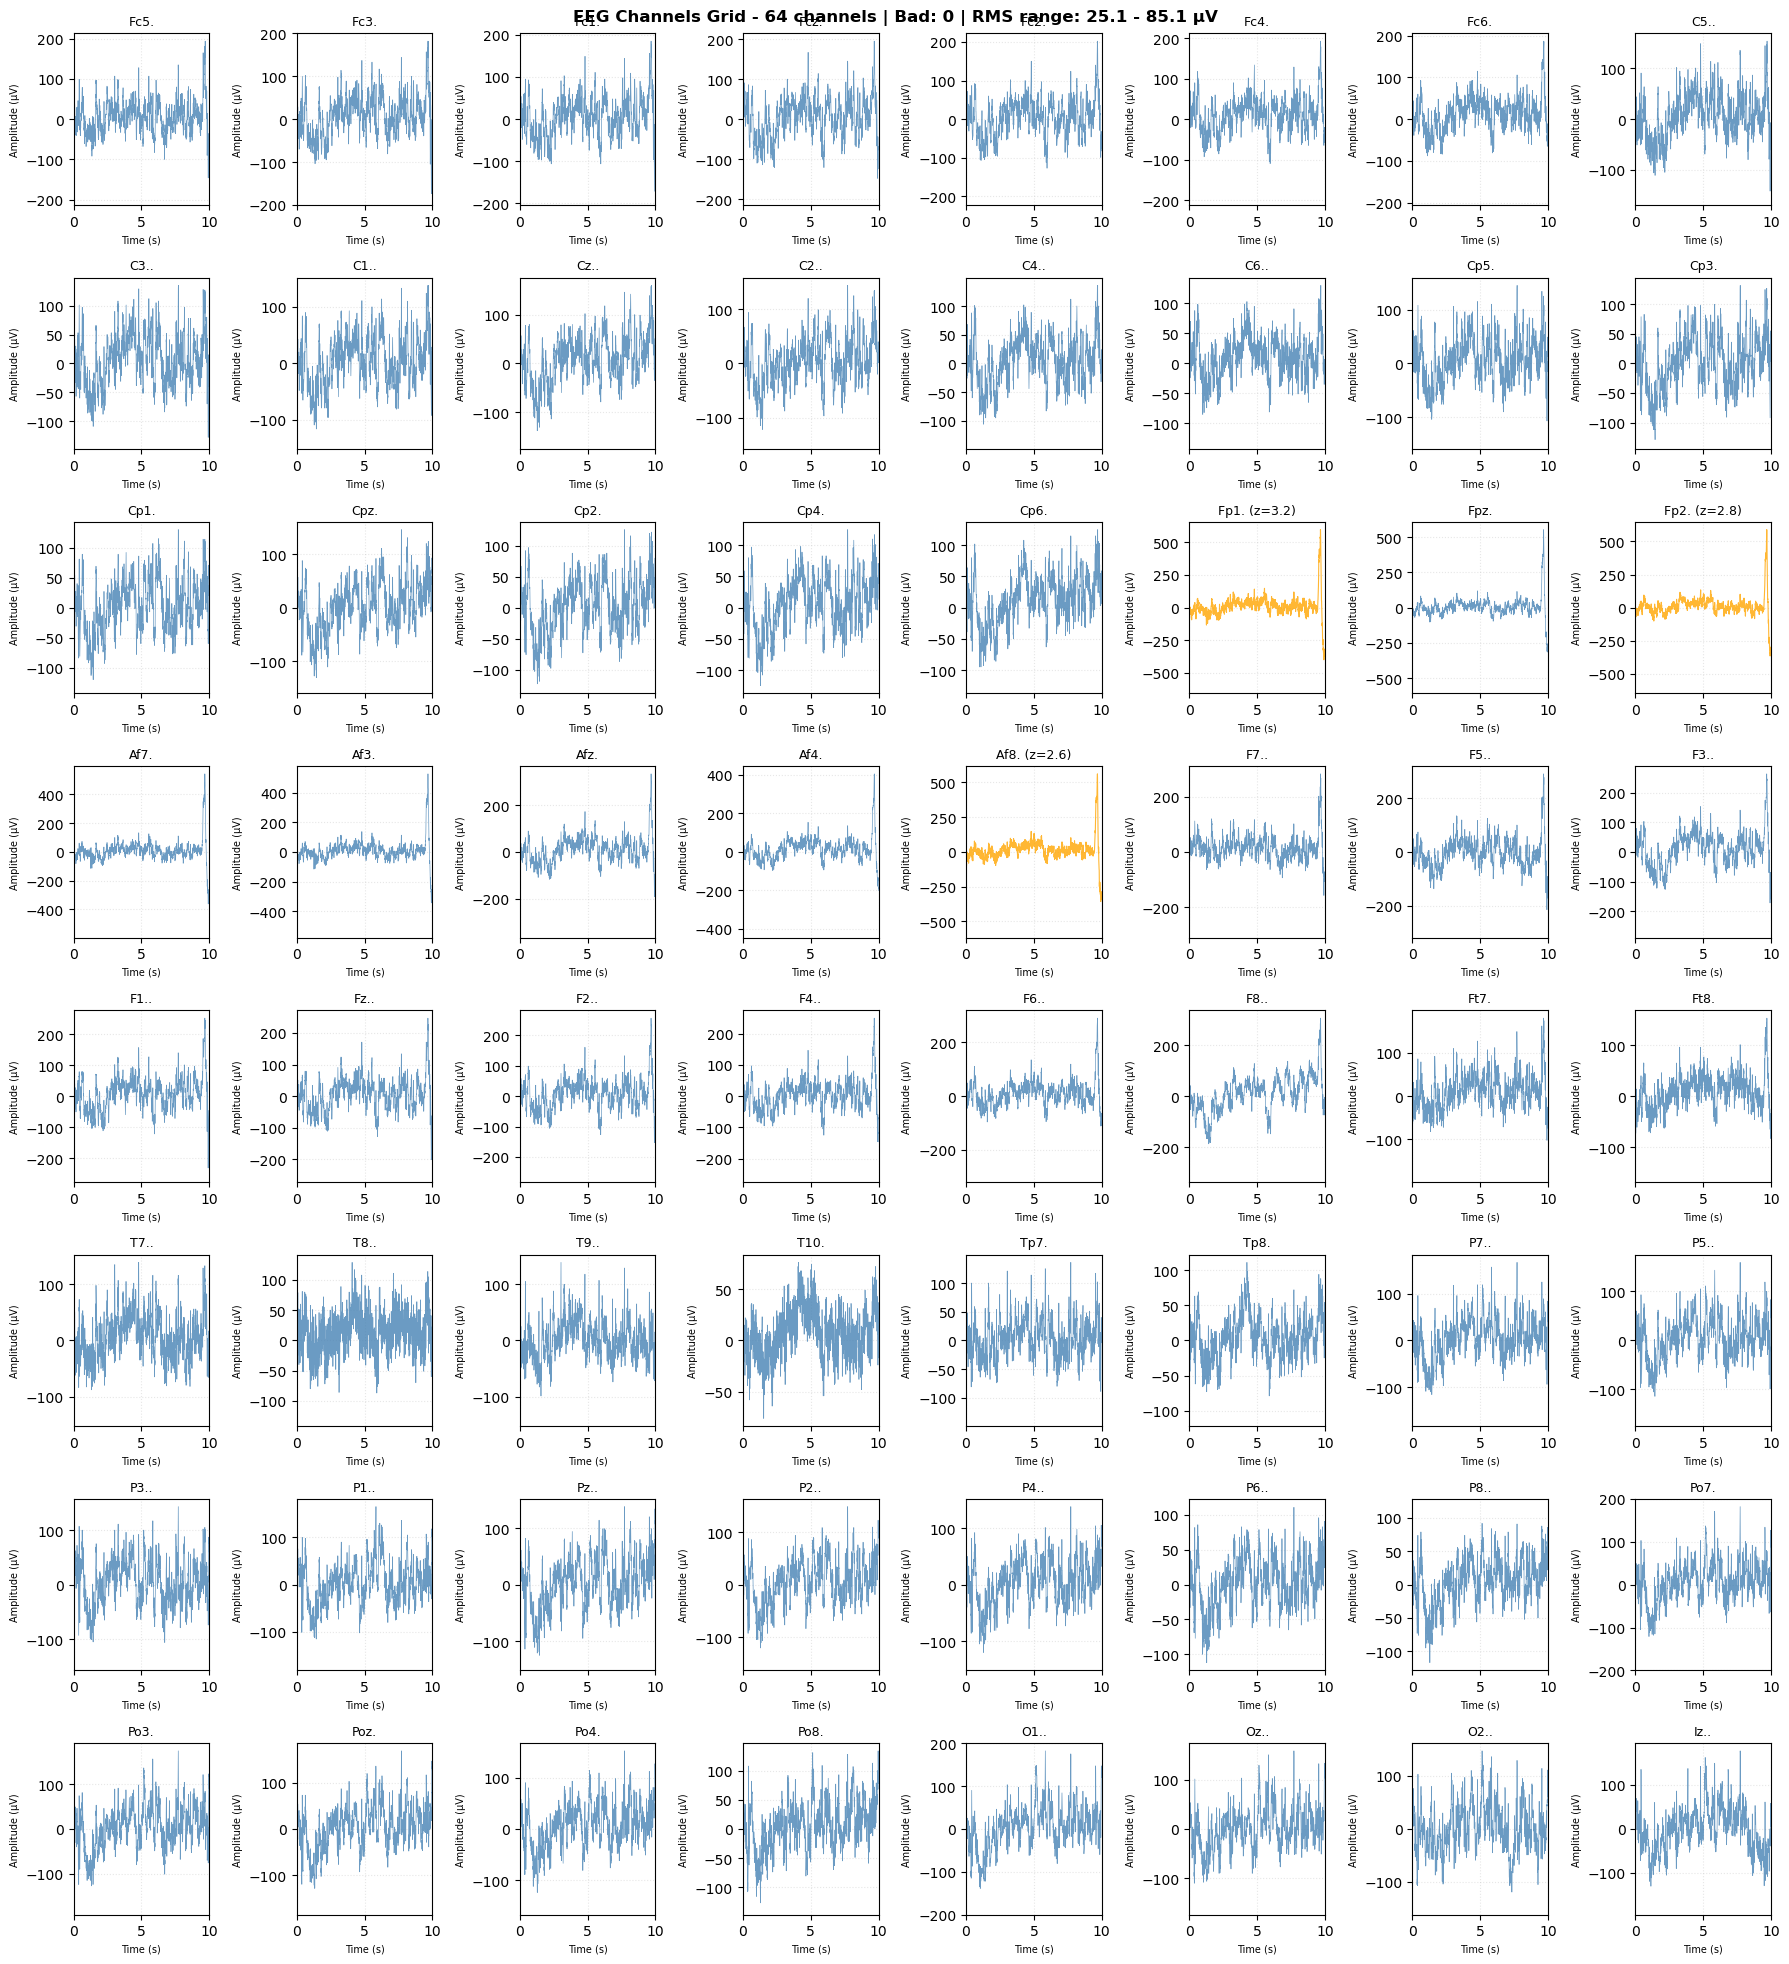


CHANNEL SUMMARY (sorted by z-score - higher = more suspicious)
Status     Channel    RMS (µV)     Z-score    Recommendation
----------------------------------------------------------------------
⚡ SUSPECT  Fp1.       85.1         3.15       CHECK MANUALLY
⚡ SUSPECT  Fp2.       80.4         2.76       CHECK MANUALLY
⚡ SUSPECT  Af8.       78.8         2.63       CHECK MANUALLY
✓ GOOD     Af7.       74.7         2.29       KEEP
✓ GOOD     Af3.       72.8         2.13       KEEP
✓ GOOD     Fpz.       71.3         2.00       KEEP
✓ GOOD     F8..       70.7         1.95       KEEP
✓ GOOD     T10.       25.1         -1.83      KEEP
✓ GOOD     Tp8.       31.2         -1.33      KEEP
✓ GOOD     Af4.       61.0         1.15       KEEP
✓ GOOD     Ft8.       33.6         -1.13      KEEP
✓ GOOD     Tp7.       33.6         -1.12      KEEP
✓ GOOD     T9..       33.9         -1.10      KEEP
✓ GOOD     P8..       34.4         -1.06      KEEP
✓ GOOD     C6..       35.3         -0.98      KEEP
✓ GOOD   

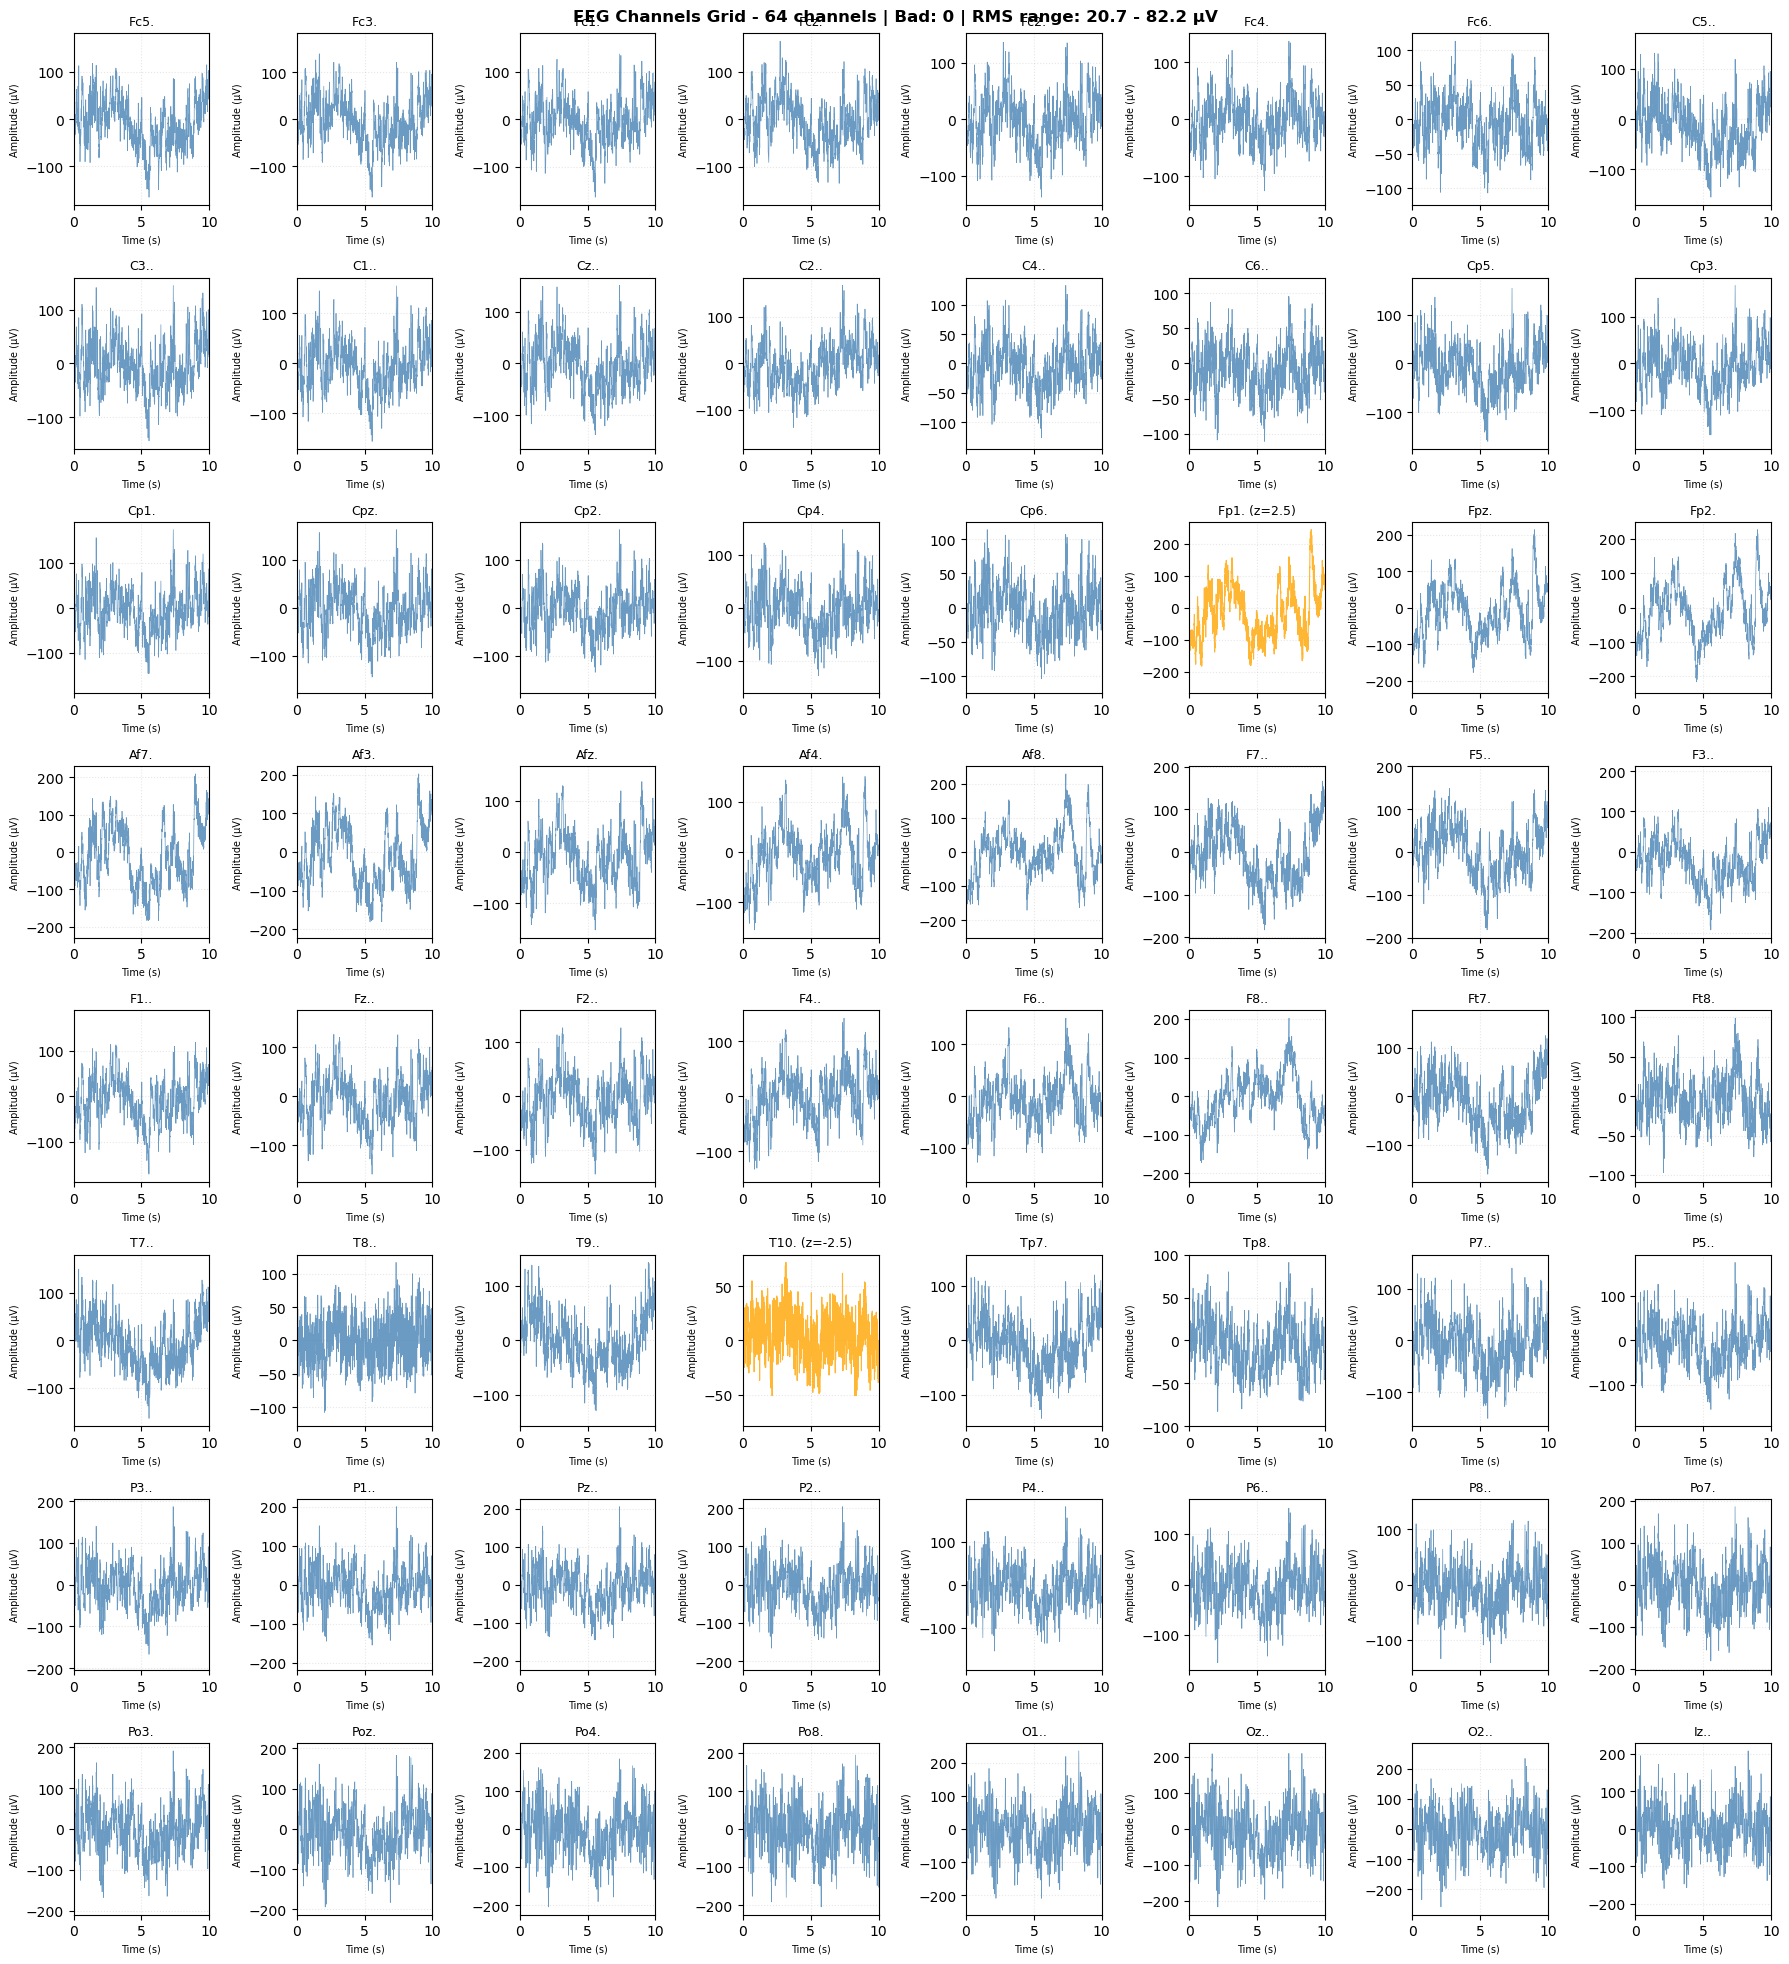


CHANNEL SUMMARY (sorted by z-score - higher = more suspicious)
Status     Channel    RMS (µV)     Z-score    Recommendation
----------------------------------------------------------------------
⚡ SUSPECT  T10.       20.7         -2.47      CHECK MANUALLY
⚡ SUSPECT  Fp1.       82.2         2.45       CHECK MANUALLY
✓ GOOD     Af7.       80.5         2.32       KEEP
✓ GOOD     Fp2.       79.0         2.20       KEEP
✓ GOOD     Af3.       78.4         2.15       KEEP
✓ GOOD     Tp8.       28.9         -1.81      KEEP
✓ GOOD     Ft8.       29.2         -1.78      KEEP
✓ GOOD     O2..       71.6         1.60       KEEP
✓ GOOD     T8..       32.3         -1.54      KEEP
✓ GOOD     Af8.       70.0         1.48       KEEP
✓ GOOD     Fpz.       69.6         1.45       KEEP
✓ GOOD     C6..       33.6         -1.43      KEEP
✓ GOOD     O1..       69.1         1.41       KEEP
✓ GOOD     Fc6.       34.1         -1.39      KEEP
✓ GOOD     Cp6.       35.8         -1.26      KEEP
✓ GOOD     Oz..    

In [9]:

print("\nPLOTTING AWAKE EEG DATA")
fig, axes, stats_awake, sus_channels_awake = plot_channels_grid_from_array(
    awake_data, sfreq=SFREQ, ch_names=CH_NAMES, duration_seconds=10,
    n_cols=8, highlight_threshold=3.5
)
print("\nPLOTTING SLEEP EEG DATA")
fig, axes, stats_sleep, sus_channel_sleep = plot_channels_grid_from_array(
    sleep_data, sfreq=SFREQ, ch_names=CH_NAMES, duration_seconds=10,
    n_cols=8, highlight_threshold=3.5
)


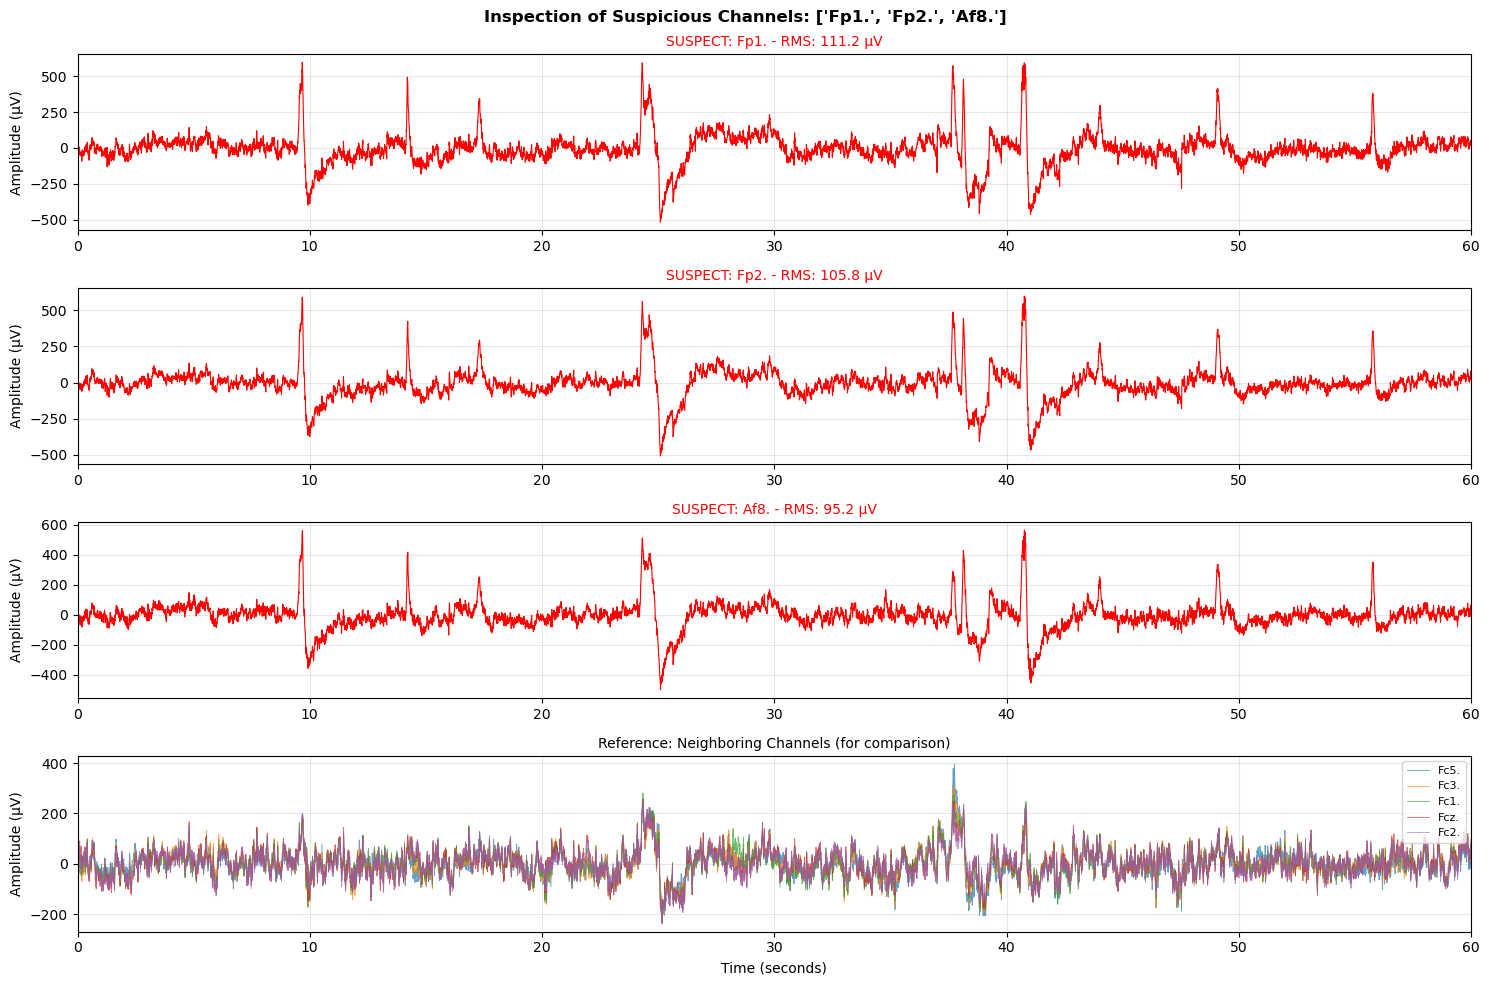

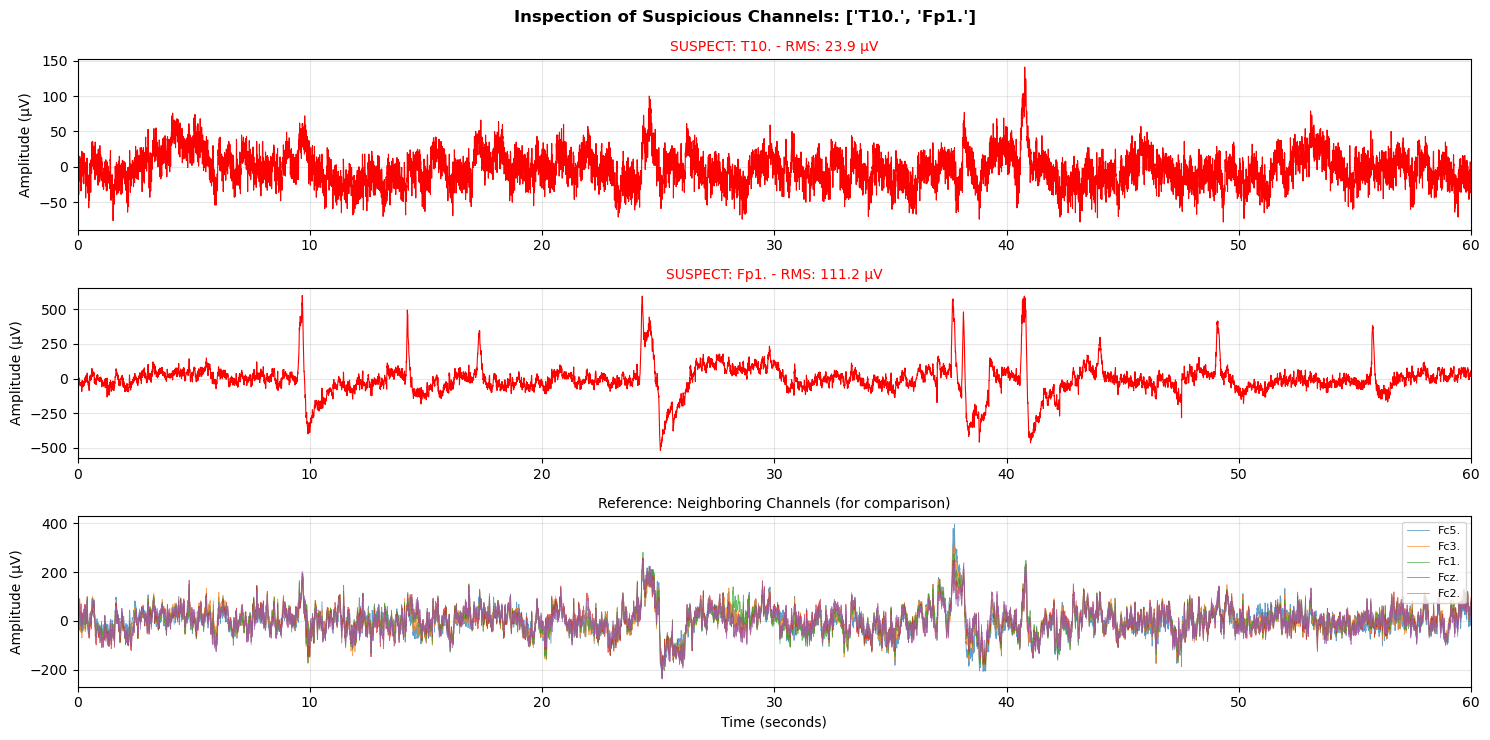

In [18]:

def inspect_suspicious_channels(data, sfreq, ch_names, suspicious_chs, duration=5):
   
    n_samples = min(int(duration * sfreq), data.shape[1])
    data_subset = data[:, :n_samples]
    times = np.arange(n_samples) / sfreq
    
    # Find indices of suspicious channels
    suspicious_idx = [ch_names.index(ch) for ch in suspicious_chs if ch in ch_names]
    suspicious_chs_filtered = [ch for ch in suspicious_chs if ch in ch_names]
    
    if len(suspicious_idx) == 0:
        print(f"WARNING: None of {suspicious_chs} found in channel names!")
        print(f"Available channels: {ch_names[:10]}...")
        return
    
    # Find neighboring channels (spatial context)
    all_frontal = ['Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'Fz', 'C3', 'C4', 'Cz']
    neighbors = [ch for ch in all_frontal if ch in ch_names and ch not in suspicious_chs_filtered]
    neighbors_idx = [ch_names.index(ch) for ch in neighbors]
    
    if len(neighbors) == 0:
        # If no frontal neighbors, take any other channels
        neighbors = [ch for ch in ch_names[:5] if ch not in suspicious_chs_filtered]
        neighbors_idx = [ch_names.index(ch) for ch in neighbors]
    
    # Plot
    n_plots = len(suspicious_chs_filtered) + 1
    fig, axes = plt.subplots(n_plots, 1, figsize=(15, n_plots * 2.5))
    
    if n_plots == 1:
        axes = [axes]
    
    # Plot suspicious channels
    for i, (ch_name, ch_idx) in enumerate(zip(suspicious_chs_filtered, suspicious_idx)):
        ax = axes[i]
        ch_data_uv = data_subset[ch_idx, :] * 1e6
        ax.plot(times, ch_data_uv, color='red', linewidth=0.8)
        ax.set_title(f'SUSPECT: {ch_name} - RMS: {np.std(ch_data_uv):.1f} µV', 
                    fontsize=10, color='red')
        ax.set_ylabel('Amplitude (µV)')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, duration])
    
    # Plot neighbors for comparison
    ax = axes[-1]
    for ch_name, ch_idx in zip(neighbors, neighbors_idx):
        ch_data_uv = data_subset[ch_idx, :] * 1e6
        ax.plot(times, ch_data_uv, linewidth=0.6, alpha=0.7, label=ch_name)
    ax.set_title(f'Reference: Neighboring Channels (for comparison)', fontsize=10)
    ax.set_ylabel('Amplitude (µV)')
    ax.set_xlabel('Time (seconds)')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, duration])
    
    plt.suptitle(f'Inspection of Suspicious Channels: {suspicious_chs_filtered}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()  
    
inspect_suspicious_channels(raw_awake.get_data(), sfreq=160, ch_names=raw_awake.ch_names, 
                           suspicious_chs=sus_channels_awake, duration=60)
inspect_suspicious_channels(raw_awake.get_data(), sfreq=160, ch_names=raw_awake.ch_names, 
                           suspicious_chs=sus_channel_sleep, duration=60)

The high amplitude at 0-1 seconds is almost certainly an eye blink or eye movement artifact. This is:

- Physiological (real biological signal, just not brain-derived)

- Expected for frontal electrodes (Fp1, Fp2 are directly above the eyes)

 removing eye blink artifacts could hurt  classification because blinks are a behavioral biomarker of wakefulness. However, the optimal approach depends on whether we  want our model to learn from brain activity alone or from combined brain + behavior signals.

Applying preprocessing to all files...


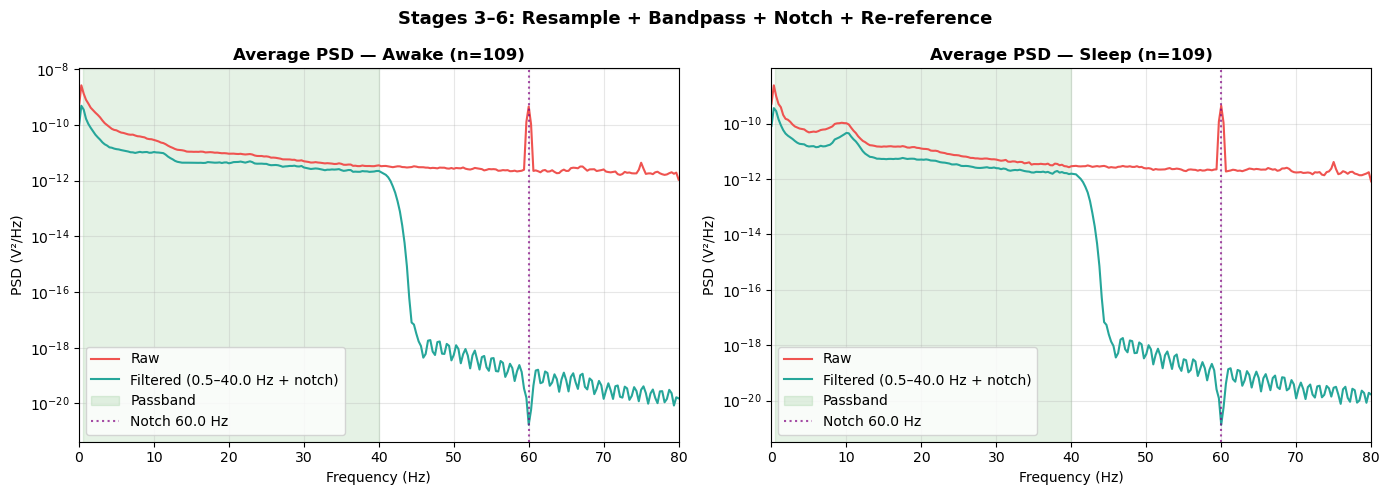

✓ Preprocessing pipeline verified


In [10]:

def preprocess_raw(raw, fs_orig=FS_ORIG, fs_target=FS_TARGET,
                   hp=HP_FREQ, lp=LP_FREQ, notch=NOTCH_FREQ):
    """
    Full signal-cleaning pipeline on an MNE Raw object (in-place copy).
    Order: resample → bandpass (EEG picks only) → notch → average re-reference.
    Returns the cleaned Raw object.
    """
    raw = raw.copy()

    if round(raw.info['sfreq']) != round(fs_target):
        raw.resample(fs_target, npad='auto')
        print(f"  Resampled {fs_orig} → {fs_target} Hz")

    # Stage 4 — Bandpass filter (EEG channels only, FIR, long filter for clean edges)
    raw.filter(l_freq=hp, h_freq=lp, picks='eeg',
               method='fir', filter_length='10s',
               l_trans_bandwidth=0.5, h_trans_bandwidth=4.0,
               verbose=False)

    # Stage 5 — Notch filter (power-line)
    raw.notch_filter(freqs=notch, picks='eeg', verbose=False)

    # Stage 6 — Average re-reference (important for ICA quality)
    raw.set_eeg_reference('average', projection=False, verbose=False)

    return raw

from scipy import signal as scipy_signal

all_awake_before, all_awake_after = [], []
all_sleep_before,  all_sleep_after  = [], []

print("Applying preprocessing to all files...")
for file_path in edf_files:
    filename = os.path.basename(file_path)
    raw_orig = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
    raw_filt = preprocess_raw(raw_orig)          # apply full pipeline

    # PSD on channel index 5 for comparison plot
    orig_1d = raw_orig.get_data(picks=[5]).flatten()
    filt_1d = raw_filt.get_data(picks=[5]).flatten()
    sfreq_orig = raw_orig.info['sfreq']
    sfreq_filt = raw_filt.info['sfreq']

    freqs_o, psd_o = scipy_signal.welch(orig_1d, fs=sfreq_orig, nperseg=512)
    freqs_f, psd_f = scipy_signal.welch(filt_1d, fs=sfreq_filt, nperseg=512)

    if 'R01' in filename:
        all_awake_before.append(psd_o); all_awake_after.append(psd_f)
    else:
        all_sleep_before.append(psd_o); all_sleep_after.append(psd_f)

# Trim to same length before averaging (resampling may change PSD length slightly)
min_len_awake = min(len(p) for p in all_awake_before + all_awake_after)
avg_awake_before = np.mean([p[:min_len_awake] for p in all_awake_before], axis=0)
avg_awake_after  = np.mean([p[:min_len_awake] for p in all_awake_after],  axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (before, after, title) in zip(axes, [
    (avg_awake_before, avg_awake_after, 'Awake'),
    (np.mean([p[:min(len(p) for p in all_sleep_before)] for p in all_sleep_before], axis=0),
     np.mean([p[:min(len(p) for p in all_sleep_after )] for p in all_sleep_after ], axis=0),
     'Sleep'),
]):
    f_vec = np.linspace(0, SFREQ/2, len(before))
    ax.semilogy(f_vec, before, label='Raw', linewidth=1.5, color='#EF5350')
    ax.semilogy(f_vec[:len(after)], after,  label=f'Filtered ({HP_FREQ}–{LP_FREQ} Hz + notch)',
                linewidth=1.5, color='#26A69A')
    ax.axvspan(HP_FREQ, LP_FREQ, alpha=0.1, color='green', label='Passband')
    ax.axvline(NOTCH_FREQ, color='purple', linestyle=':', alpha=0.7, label=f'Notch {NOTCH_FREQ} Hz')
    ax.set_xlim([0, 80]); ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD (V²/Hz)')
    ax.set_title(f'Average PSD — {title} (n={len(edf_files)//2})', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Stages 3–6: Resample + Bandpass + Notch + Re-reference', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print("✓ Preprocessing pipeline verified")




Selected channel: Index 32 -> Name: 'F1..'
Created filtered copy of awake data
Created filtered copy of sleep data

1. COMPARING SINGLE CHANNEL: F1.. (index 32)


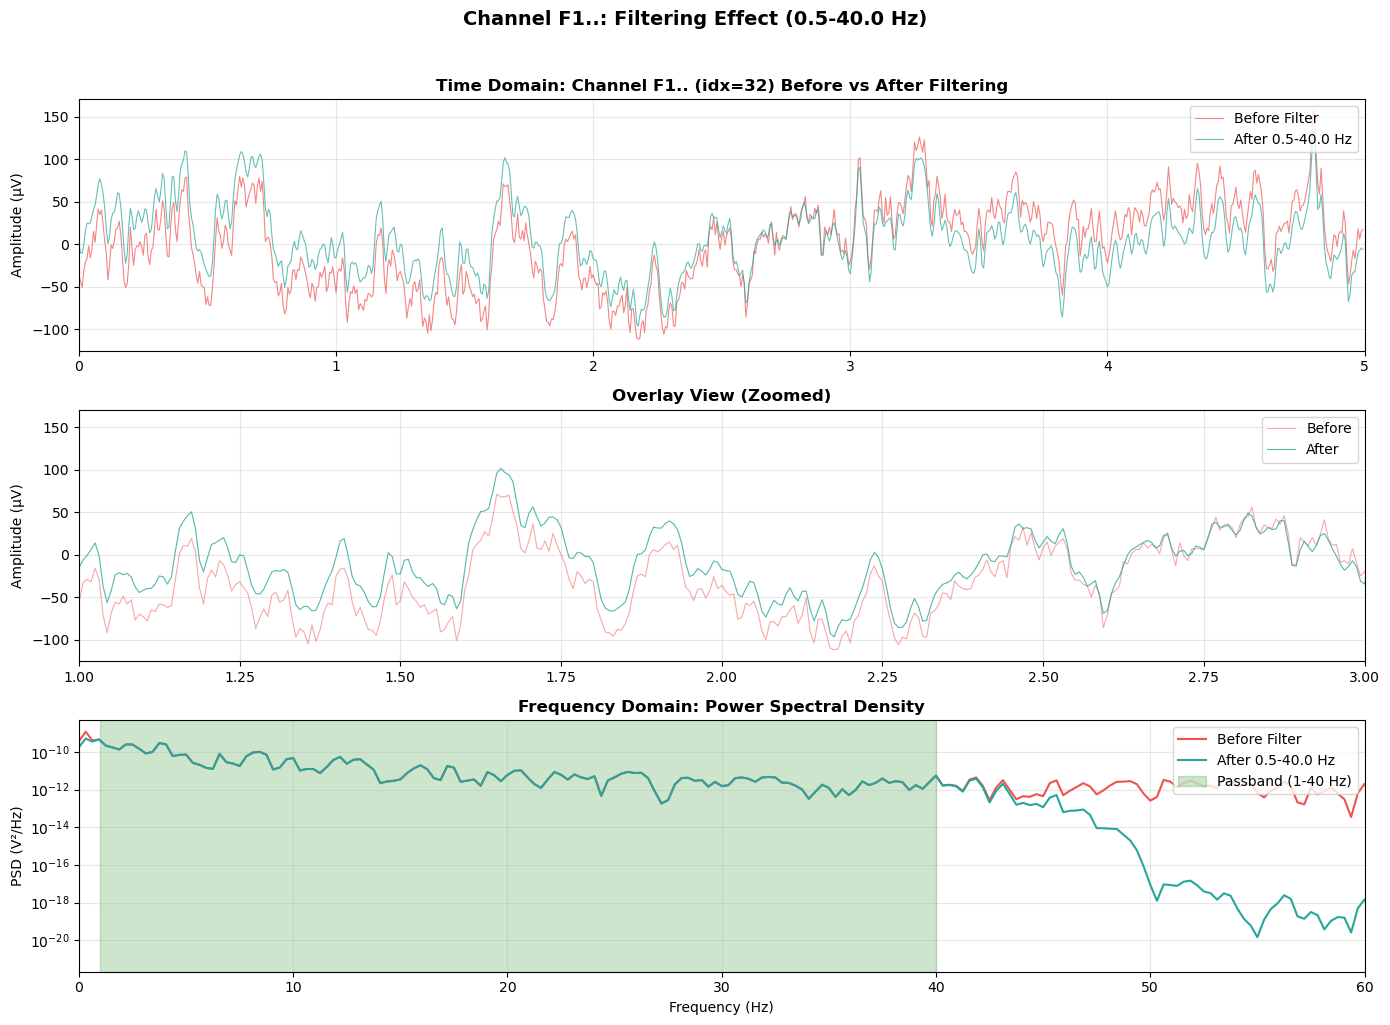


📊 Channel F1.. (idx=32) Statistics:
   Before filtering - Mean: 0.98 µV, Std: 48.96 µV
   After filtering  - Mean: 5.37 µV, Std: 39.97 µV
   Noise reduction: 18.4%
RMS amplitude: 40.33 µV


In [11]:
# COMPARE SINGLE CHANNEL USING INDEX (NO NAME LOOKUP)

def compare_single_channel_by_index(raw_original, raw_filtered, channel_idx, channel_name, sfreq, duration=5):
    """
    Compare a single channel before and after filtering using channel index.
    
    Parameters:
    - raw_original: MNE Raw object (unfiltered)
    - raw_filtered: MNE Raw object (filtered)
    - channel_idx: integer index of channel (0-63)
    - channel_name: name for display purposes
    - sfreq: sampling frequency
    - duration: seconds to plot
    """
    # Get data for duration
    n_samples = int(duration * sfreq)
    
    # Original data
    orig_data, times = raw_original[channel_idx, :n_samples]
    if orig_data.ndim > 1:
        orig_data = orig_data.flatten()
    
    # Filtered data
    filt_data, _ = raw_filtered[channel_idx, :n_samples]
    if filt_data.ndim > 1:
        filt_data = filt_data.flatten()
    
    # Convert to microvolts
    orig_data_uv = orig_data * 1e6
    filt_data_uv = filt_data * 1e6
    
    # Create plot
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # Plot 1: Time domain comparison
    axes[0].plot(times, orig_data_uv, color='#EF5350', alpha=0.7, linewidth=0.8, label='Before Filter')
    axes[0].plot(times, filt_data_uv, color='#26A69A', alpha=0.7, linewidth=0.8, label=f'After {HP_FREQ}-{LP_FREQ} Hz')
    axes[0].set_title(f'Time Domain: Channel {channel_name} (idx={channel_idx}) Before vs After Filtering', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Amplitude (µV)', fontsize=10)
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim([0, duration])
    
    # Plot 2: Overlay (zoomed for detail)
    axes[1].plot(times, orig_data_uv, color='#EF5350', alpha=0.5, linewidth=0.8, label='Before')
    axes[1].plot(times, filt_data_uv, color='#26A69A', alpha=0.8, linewidth=0.8, label='After')
    axes[1].set_title(f'Overlay View (Zoomed)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Amplitude (µV)', fontsize=10)
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim([1, 3])
    
    # Plot 3: PSD comparison
    from scipy import signal
    freqs_orig, psd_orig = signal.welch(orig_data, fs=sfreq, nperseg=512)
    freqs_filt, psd_filt = signal.welch(filt_data, fs=sfreq, nperseg=512)
    
    axes[2].semilogy(freqs_orig, psd_orig, color='#EF5350', linewidth=1.5, label='Before Filter')
    axes[2].semilogy(freqs_filt, psd_filt, color='#26A69A', linewidth=1.5, label=f'After {HP_FREQ}-{LP_FREQ} Hz')
    axes[2].axvspan(1, 40, alpha=0.2, color='green', label='Passband (1-40 Hz)')
    axes[2].set_xlim([0, 60])
    axes[2].set_xlabel('Frequency (Hz)', fontsize=10)
    axes[2].set_ylabel('PSD (V²/Hz)', fontsize=10)
    axes[2].set_title('Frequency Domain: Power Spectral Density', fontsize=12, fontweight='bold')
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)
    
    plt.suptitle(f'Channel {channel_name}: Filtering Effect ({HP_FREQ}-{LP_FREQ} Hz)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n📊 Channel {channel_name} (idx={channel_idx}) Statistics:")
    print(f"   Before filtering - Mean: {np.mean(orig_data_uv):.2f} µV, Std: {np.std(orig_data_uv):.2f} µV")
    print(f"   After filtering  - Mean: {np.mean(filt_data_uv):.2f} µV, Std: {np.std(filt_data_uv):.2f} µV")
    print(f"   Noise reduction: {(1 - np.std(filt_data_uv)/np.std(orig_data_uv))*100:.1f}%")
    # Better amplitude metrics after filtering
    amplitude_rms = np.sqrt(np.mean(filt_data**2))
   

    print(f"RMS amplitude: {amplitude_rms*1e6:.2f} µV")  # Most informative
    

CHANNEL_TO_ANALYZE = 32
CHANNEL_NAME = raw_awake.ch_names[CHANNEL_TO_ANALYZE]

print(f"\n\nSelected channel: Index {CHANNEL_TO_ANALYZE} -> Name: '{CHANNEL_NAME}'")

# Create filtered copies if you don't have them
if 'raw_awake_filt' not in dir():
    raw_awake_filt = raw_awake.copy()
    raw_awake_filt.filter(l_freq=HP_FREQ, h_freq=LP_FREQ, method='fir', verbose=False)
    print("Created filtered copy of awake data")

if 'raw_sleep_filt' not in dir():
    raw_sleep_filt = raw_sleep.copy()
    raw_sleep_filt.filter(l_freq=HP_FREQ, h_freq=LP_FREQ, method='fir', verbose=False)
    print("Created filtered copy of sleep data")

# Now compare using channel INDEX instead of name
print("\n" + "="*80)
print(f"1. COMPARING SINGLE CHANNEL: {CHANNEL_NAME} (index {CHANNEL_TO_ANALYZE})")
print("="*80)

compare_single_channel_by_index(
    raw_original=raw_awake,
    raw_filtered=raw_awake_filt,
    channel_idx=CHANNEL_TO_ANALYZE,
    channel_name=CHANNEL_NAME,
    sfreq=SFREQ,
    duration=5
)

As we can see from the dataset and its mean amplitude the offsets of eeg signals have been removed since it's just 1uv (the offset of an eeg signal is normally 50uv becuase of electrode_skin potential)

it means our high-pass filter successfully removed DC offset and low-frequency drift, centering you signal at zero where it belongs! The actual signal amplitude (RMS) should decrease, showing noise reduction.



--- 
# STAGE 7: ICA — Artifact Removal (EOG + muscle)

In [12]:

from mne.preprocessing import ICA

def run_ica(raw_clean, label, seed=SEED):
   
    n_components = min(20, raw_clean.get_data(picks='eeg').shape[0] - 1)

    ica = ICA(n_components=n_components, method='fastica',
              random_state=seed, max_iter='auto')
    ica.fit(raw_clean, picks='eeg', verbose=False)

    # ── Strategy 1: MNE built-in EOG detection via frontal channels 
    frontal_candidates = ['Fp1', 'Fp2', 'FP1', 'FP2', 'AF3', 'AF4', 'F3', 'F4']
    eog_ch = next((ch for ch in frontal_candidates
                   if ch in raw_clean.ch_names or ch.upper() in
                   [c.upper() for c in raw_clean.ch_names]), None)

    eog_indices, eog_scores = [], []
    if eog_ch:
        try:
            eog_indices, eog_scores = ica.find_bads_eog(
                raw_clean, ch_name=eog_ch, threshold=3.0, verbose=False)
        except Exception:
            eog_indices = []

    # ── Strategy 2: fallback — correlation with first two channels 
    if not eog_indices:
        ica_src = ica.get_sources(raw_clean).get_data()
        ref_data = raw_clean.get_data(picks='eeg')[0]
        scores = np.array([
            np.abs(np.corrcoef(ica_src[k], ref_data)[0, 1])
            for k in range(n_components)
        ])
        eog_indices = list(np.where(scores > 0.30)[0])

    ica.exclude = eog_indices
    ica.apply(raw_clean, verbose=False)

    print(f'[{label}] ICA: {n_components} components, '
          f'{len(eog_indices)} removed: {eog_indices}')
    return ica

# Apply full pipeline + ICA on representative files
raw_awake_mne = preprocess_raw(
    mne.io.read_raw_edf(awake_file, preload=True, verbose=False))
raw_sleep_mne = preprocess_raw(
    mne.io.read_raw_edf(sleep_file, preload=True, verbose=False))

ica_awake = run_ica(raw_awake_mne, 'Awake')
ica_sleep = run_ica(raw_sleep_mne, 'Sleep')
print('✓ ICA artifact removal complete')


[Awake] ICA: 20 components, 3 removed: [2, 3, 5]
[Sleep] ICA: 20 components, 3 removed: [2, 7, 11]
✓ ICA artifact removal complete


---
## 1. Data Loading & Preprocessing

The Kaggle dataset (`eeg-sleep-vs-awake`) stores **EEG spectrogram images** in two folders:
```
/kaggle/input/eeg-sleep-vs-awake/
    sleep/   ← NREM / REM spectrograms
    awake/   ← wakefulness spectrograms
```
**Preprocessing steps applied:**
1. Resize to 64×64 (uniform spatial dimensions)
2. Convert to grayscale (EEG spectrograms are single-channel energy maps)
3. Convert to tensor and normalise to `[-1, 1]` using `mean=0.5, std=0.5`
4. 70 / 15 / 15 train–val–test split

# Why Mel Spectrograms for Sleep vs. Wake EEG Classification?

## 1. The Core Problem: What Makes Sleep EEG Different?

Sleep-wake classification relies on detecting distinct rhythmic patterns in the EEG signal:

| State | Dominant Rhythms | Frequency Range | Characteristics |
| :--- | :--- | :--- | :--- |
| **Wake** | Alpha, Beta | 8-13 Hz, 13-30 Hz | Low amplitude, high frequency, desynchronized |
| **NREM Sleep** | Delta, Theta, Spindles | 0.5-4 Hz, 4-8 Hz, 11-16 Hz | High amplitude, low frequency, synchronized |
| **REM Sleep** | Mixed (Theta + Beta) | 4-8 Hz, 13-30 Hz | Sawtooth waves, low amplitude |

**Key insight:** The most discriminative information for sleep vs. wake lies in the **low-frequency range (0.5-30 Hz)**. Frequencies above ~30 Hz (gamma) contain mostly muscle artifact and noise, not sleep-specific neural activity.

---

## 2. Why Mel Spectrogram? The Physiological Justification

### 2.1. The Mel Scale Matches Human Auditory Perception (and Sleep Scoring)

The Mel scale is nonlinear: it provides **high resolution at low frequencies** and **low resolution at high frequencies**.
- Sleep scoring by human experts focuses heavily on **low-frequency discrimination** (distinguishing 1 Hz delta from 4 Hz theta from 12 Hz spindles)
- The Mel scale naturally emphasizes these clinically relevant differences
- High-frequency noise (>30 Hz) is automatically down-weighted without requiring aggressive low-pass filtering

In [14]:
 
import os, re, warnings
import numpy as np
import mne
from pathlib import Path
from scipy import signal as scipy_signal
from skimage.transform import resize as sk_resize
import librosa

ARTIFACT_AMP   = 170e-6      
ARTIFACT_PROP  = 0.10       
MAX_BAD_CH_FRAC = 0.25       
N_CHANNELS     = 64
SEED           = 42



def preprocess_raw(raw, fs_orig=FS_ORIG, fs_target=FS_TARGET,
                   hp=HP_FREQ, lp=LP_FREQ, notch=NOTCH_FREQ):
  
    raw = raw.copy()

    if round(raw.info['sfreq']) != round(fs_target):
        raw.resample(fs_target, npad='auto')
        print(f"  Resampled {fs_orig} → {fs_target} Hz")

    # This prevents filter ringing from large offset steps at segment edges.
    data = raw.get_data(picks='eeg')
    data -= data.mean(axis=1, keepdims=True)
    raw._data[mne.pick_types(raw.info, eeg=True), :] = data

def eeg_to_mel_spectrogram(signal_1d, sfreq, n_mels=64, fmin=0.5, fmax=40.0,
                            n_fft=256, hop_length=32):
    """Convert a 1-D EEG epoch to a Mel spectrogram (dB scale)."""
    x = signal_1d.astype(np.float32)
    mel = librosa.feature.melspectrogram(
        y=x, sr=int(sfreq), n_fft=n_fft, hop_length=hop_length,
        n_mels=n_mels, fmin=fmin, fmax=fmax, power=2.0
    )
    mel_db = librosa.power_to_db(mel + 1e-10, ref=np.max)
    return mel_db   # (n_mels, T)

# STAGE 8  process_edf_to_spectrograms() 

def process_edf_to_spectrograms(
        file_path,
        epoch_dur      = EPOCH_DUR,
        artifact_amp   = ARTIFACT_AMP,
        artifact_prop  = ARTIFACT_PROP,
        max_bad_ch_frac = MAX_BAD_CH_FRAC, 
        n_mels         = 64,
        img_size       = 64,
        max_channels   = 16):

   ## Load one EDF → preprocess → epoch → artifact rejection → Mel spectrograms.

    filename   = os.path.basename(file_path)
    label      = 0 if 'R01' in filename else 1
    subject_id = re.split(r'R\d+', filename)[0]

    # Load + full preprocessing pipeline
    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
   

    sfreq      = raw.info['sfreq']
    epoch_samp = int(epoch_dur * sfreq)
    eeg_data   = raw.get_data(picks='eeg')          # (n_ch, n_times)
    n_ch, n_t  = eeg_data.shape
    n_ch_use   = min(n_ch, max_channels)
    n_epochs   = n_t // epoch_samp

    specs = []
    rejection_stats = {
        'total':          n_epochs,
        'full_rejected':  0,   # whole epoch thrown away (majority of ch bad)
        'ch_zeroed':      0,   # epoch kept but N bad channels zeroed out
        'clean':          0,   # epoch accepted without any intervention
    }

    for ep in range(n_epochs):
        start = ep * epoch_samp
        stop  = start + epoch_samp
        epoch = eeg_data[:n_ch_use, start:stop].copy()   # (n_ch_use, epoch_samp)

        # Stage A: per-channel artifact detection 
        n_samples = epoch.shape[1]
        n_ch_epoch = epoch.shape[0]

        # For each channel: what fraction of samples exceeds the threshold?
        proportion_above = (np.abs(epoch) > artifact_amp).sum(axis=1) / n_samples
        bad_ch_mask = proportion_above > artifact_prop         # bool (n_ch_use,)
        bad_ch_frac = bad_ch_mask.sum() / n_ch_epoch

        # Stage B: decide epoch fate 
        if bad_ch_frac > max_bad_ch_frac:
            # Majority of channels are bad → unrecoverable → discard epoch
            rejection_stats['full_rejected'] += 1
            continue

        if bad_ch_mask.any():
            # Minority of channels are bad → zero them out, keep epoch
            epoch[bad_ch_mask, :] = 0.0
            rejection_stats['ch_zeroed'] += 1
        else:
            rejection_stats['clean'] += 1

        #  NEW: per-epoch, per-channel linear detrend
        # Removes residual slow drift at epoch boundaries that survived
        # the 0.5 Hz high-pass filter (happens especially at recording edges).
        for ch in range(n_ch_epoch):
            epoch[ch] = scipy_signal.detrend(epoch[ch], type='linear')

        #  Per-epoch, per-channel z-score normalisation (UNCHANGED)
        mu  = epoch.mean(axis=1, keepdims=True)
        sig = epoch.std(axis=1, keepdims=True) + 1e-8
        epoch_z = (epoch - mu) / sig

        # ── Stage 9: Mel spectrogram per channel + stack (UNCHANGED)
        channel_mels = []
        for ch in range(n_ch_use):
            mel = eeg_to_mel_spectrogram(epoch_z[ch], sfreq=sfreq, n_mels=n_mels)
            mel_resized = sk_resize(mel, (img_size, img_size),
                                    preserve_range=True, anti_aliasing=True)
            lo, hi = mel_resized.min(), mel_resized.max()
            if hi > lo:
                mel_resized = (mel_resized - lo) / (hi - lo)
            channel_mels.append(mel_resized.astype(np.float32))

        specs.append(np.stack(channel_mels, axis=0))   # (n_ch_use, H, W)

    if len(specs) == 0:
        return None, label, subject_id, rejection_stats

    return np.stack(specs, axis=0), label, subject_id, rejection_stats


# MAIN LOOP  — drop-in replacement for your original loop

def run_preprocessing(edf_files):
  
    print("Processing all EDF files → Mel spectrograms (fixed pipeline)...")
    print(f"  Artifact threshold : {ARTIFACT_AMP*1e6:.0f} µV")
    print(f"  Proportion guard   : >{ARTIFACT_PROP:.0%} of samples per channel")
    print(f"  Max bad ch fraction: >{MAX_BAD_CH_FRAC:.0%} of channels → full reject")
    print()

    all_specs, all_labels, all_subjects = [], [], []
    all_stats = []

    for i, fp in enumerate(edf_files):
        fname = os.path.basename(fp)
        print(f"  [{i+1:02d}/{len(edf_files):02d}] {fname}", end='  ')

        result = process_edf_to_spectrograms(fp)
        specs, lbl, subj, stats = result

        if specs is not None:
            all_specs.append(specs)
            all_labels.extend([lbl]   * len(specs))
            all_subjects.extend([subj] * len(specs))
            kept = stats['clean'] + stats['ch_zeroed']
            print(f"→ {len(specs)} epochs  "
                  f"(clean={stats['clean']}, ch_zeroed={stats['ch_zeroed']}, "
                  f"full_rejected={stats['full_rejected']})")
        else:
            print("→ 0 valid epochs (all rejected)")

        all_stats.append(stats)

    X       = np.concatenate(all_specs, axis=0)
    y       = np.array(all_labels)
    groups  = np.array(all_subjects)

    total_epochs    = sum(s['total']         for s in all_stats)
    full_rejected   = sum(s['full_rejected'] for s in all_stats)
    ch_zeroed       = sum(s['ch_zeroed']     for s in all_stats)
    clean           = sum(s['clean']         for s in all_stats)
    kept            = clean + ch_zeroed

    print(f"\n{'='*60}")
    print(f"  Total epochs    : {total_epochs}")
    print(f"  Clean (kept)    : {clean}  ({100*clean/total_epochs:.1f} %)")
    print(f"  Ch-zeroed (kept): {ch_zeroed}  ({100*ch_zeroed/total_epochs:.1f} %)")
    print(f"  Full rejected   : {full_rejected}  ({100*full_rejected/total_epochs:.1f} %)")
    print(f"  ──────────────────────────────────────")
    print(f"  Total kept      : {kept}  ({100*kept/total_epochs:.1f} %)")
    print(f"{'='*60}")
    print(f"\n✓ Dataset: {X.shape}  (epochs × channels × H × W)")
    print(f"  Awake: {(y==0).sum()}  |  Sleep: {(y==1).sum()}")
    print(f"  Unique subjects: {len(np.unique(groups))}")

    return X, y, groups   

X, y, groups = run_preprocessing(edf_files)


# ── 2. Subject-level train / val / test split (UNCHANGED from your original) 
from sklearn.model_selection import GroupShuffleSplit

print("\nSplitting by subject (no leakage)...")
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
trainval_idx, test_idx = next(gss_test.split(X, y, groups))

X_trainval, y_trainval = X[trainval_idx], y[trainval_idx]
X_test,     y_test     = X[test_idx],     y[test_idx]
groups_tv               = groups[trainval_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15/0.85, random_state=SEED)
train_idx, val_idx = next(gss_val.split(X_trainval, y_trainval, groups_tv))

X_train, y_train = X_trainval[train_idx], y_trainval[train_idx]
X_val,   y_val   = X_trainval[val_idx],   y_trainval[val_idx]

print(f"  Train : {len(X_train)} epochs  "
      f"(subjects: {len(np.unique(groups_tv[train_idx]))})")
print(f"  Val   : {len(X_val)}   epochs  "
      f"(subjects: {len(np.unique(groups_tv[val_idx]))})")
print(f"  Test  : {len(X_test)}  epochs  "
      f"(subjects: {len(np.unique(groups[test_idx]))})")

N_INPUT_CH = X.shape[1]
print(f"\n  Input tensor shape per sample: ({N_INPUT_CH}, {IMG_SIZE}, {IMG_SIZE})")

# ── 2.5 Define EEGMelDataset Class (ADD THIS BEFORE SECTION 3) ────────────────────
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class EEGMelDataset(Dataset):
    """Custom Dataset for EEG Mel-spectrogram data"""
    
    def __init__(self, X, y, augment=False):
        """
        Args:
            X: Input features (mel-spectrograms) - shape (n_samples, n_channels, H, W)
            y: Labels - shape (n_samples,)
            augment: Whether to apply data augmentation
        """
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        self.augment = augment
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x = self.X[idx]  # (n_channels, H, W)
        y = self.y[idx]
        
        # Apply augmentation if enabled
        if self.augment:
            x = self._augment(x)
            
        return x, y
    
    def _augment(self, x):
        """Apply data augmentation to EEG spectrograms"""
        # Copy to avoid modifying original
        x = x.clone()
        
        # 1. Gaussian noise (add small random noise)
        if np.random.random() > 0.5:
            noise = torch.randn_like(x) * 0.05
            x = x + noise
        
        # 2. Time masking (mask random time segments)
        if np.random.random() > 0.6:
            T = x.shape[-1]  # time dimension
            mask_len = np.random.randint(1, max(2, T // 10))
            mask_start = np.random.randint(0, T - mask_len)
            x[:, :, mask_start:mask_start + mask_len] = 0
        
        # 3. Frequency masking (mask random frequency bins)
        if np.random.random() > 0.6:
            F = x.shape[-2]  # frequency dimension
            mask_len = np.random.randint(1, max(2, F // 10))
            mask_start = np.random.randint(0, F - mask_len)
            x[:, mask_start:mask_start + mask_len, :] = 0
        
        # 4. Channel dropout (randomly zero out entire channels)
        if np.random.random() > 0.7:
            n_channels = x.shape[0]
            dropout_ch = np.random.randint(0, n_channels)
            x[dropout_ch, :, :] = 0
        
        # 5. Mixup (optional - requires batch-level operation, skip for per-sample)
        
        # Clip to reasonable range
        x = torch.clamp(x, -3, 3)
        
        return x

# Optional: Add a variant with more aggressive augmentation
class EEGMelDatasetAugmented(EEGMelDataset):
    """Extended dataset with more augmentation options"""
    
    def _augment(self, x):
        x = super()._augment(x)
        
        # Add random scaling
        if np.random.random() > 0.5:
            scale = torch.FloatTensor(1).uniform_(0.8, 1.2)
            x = x * scale
        
        # Add random time shift (circular shift)
        if np.random.random() > 0.7:
            shift = np.random.randint(-x.shape[-1]//4, x.shape[-1]//4)
            x = torch.roll(x, shifts=shift, dims=-1)
        
        return x

# ── 3. Dataset & DataLoader (UNCHANGED from your original) ────────────────────
train_ds = EEGMelDataset(X_train, y_train, augment=True)
val_ds   = EEGMelDataset(X_val,   y_val,   augment=False)
test_ds  = EEGMelDataset(X_test,  y_test,  augment=False)

def make_loaders(tr, va, te, batch=BATCH):
    kw = dict(num_workers=0, pin_memory=False)
    return (DataLoader(tr, batch, shuffle=True,  **kw),
            DataLoader(va, batch, shuffle=False, **kw),
            DataLoader(te, batch, shuffle=False, **kw))

train_ldr, val_ldr, test_ldr = make_loaders(train_ds, val_ds, test_ds)
train_loader = train_ldr
val_loader   = val_ldr
test_loader  = test_ldr

print(f"\n✓ DataLoaders ready")
print(f"  Train batches: {len(train_ldr)}  |  Val: {len(val_ldr)}  |  Test: {len(test_ldr)}")

# Quick sanity check
xb, yb = next(iter(train_ldr))
print(f"  Batch shape : {xb.shape}  (batch × channels × H × W)")
print(f"  Value range : [{xb.min():.2f}, {xb.max():.2f}]  (expected ~[-1, 1])")
print(f"  Labels      : {yb[:8].tolist()}  (0=Awake, 1=Sleep)")

Processing all EDF files → Mel spectrograms (fixed pipeline)...
  Artifact threshold : 170 µV
  Proportion guard   : >10% of samples per channel
  Max bad ch fraction: >25% of channels → full reject

  [01/218] S001R01.edf  → 15 epochs  (clean=13, ch_zeroed=2, full_rejected=0)
  [02/218] S001R02.edf  → 15 epochs  (clean=15, ch_zeroed=0, full_rejected=0)
  [03/218] S002R01.edf  → 15 epochs  (clean=15, ch_zeroed=0, full_rejected=0)
  [04/218] S002R02.edf  → 15 epochs  (clean=15, ch_zeroed=0, full_rejected=0)
  [05/218] S003R01.edf  → 15 epochs  (clean=2, ch_zeroed=13, full_rejected=0)
  [06/218] S003R02.edf  → 15 epochs  (clean=0, ch_zeroed=15, full_rejected=0)
  [07/218] S004R01.edf  → 15 epochs  (clean=15, ch_zeroed=0, full_rejected=0)
  [08/218] S004R02.edf  → 15 epochs  (clean=15, ch_zeroed=0, full_rejected=0)
  [09/218] S005R01.edf  → 15 epochs  (clean=15, ch_zeroed=0, full_rejected=0)
  [10/218] S005R02.edf  → 15 epochs  (clean=15, ch_zeroed=0, full_rejected=0)
  [11/218] S006R01.e

---
## A. Baseline CNN (from scratch)

**Architecture:**
```
Input (1×64×64)
  └─ Conv(3×3, 32) → BN → ReLU → MaxPool(2×2)   → 32×32×32
  └─ Conv(3×3, 64) → BN → ReLU → MaxPool(2×2)   → 64×16×16
  └─ Conv(3×3,128) → BN → ReLU → MaxPool(2×2)   → 128×8×8
  └─ Flatten → FC(256) → Dropout(0.5) → FC(2)
```

In [ ]:
# ── Baseline CNN updated to accept multi-channel Mel input ───────────────────
# N_INPUT_CH is set automatically from the data shape (not hard-coded to 1)

class BaselineCNN(nn.Module):
   
    def __init__(self, in_ch=None, num_classes=2):
        super().__init__()
        if in_ch is None:
            in_ch = N_INPUT_CH   # set from data at runtime
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_ch, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

baseline = BaselineCNN(in_ch=N_INPUT_CH).to(DEVICE)
print(f'Baseline CNN — input channels: {N_INPUT_CH}')
print(f'Baseline CNN — trainable parameters: {count_params(baseline):,}')
print(baseline)


Baseline CNN — input channels: 16
Baseline CNN — trainable parameters: 2,195,362
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten

In [ ]:
def train_model(model, tr_ldr, va_ldr,
                epochs=EPOCHS, lr=LR, tag=''):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    hist = defaultdict(list)

    for ep in range(1, epochs + 1):
        #  train 
        model.train()
        tl = tc = tt = 0
        t0 = time.time()
        for xb, yb in tr_ldr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
            with torch.no_grad():
                out  = model(xb)
                tl  += criterion(out, yb).item() * len(yb)
                tc  += (out.argmax(1) == yb).sum().item()
                tt  += len(yb)
        scheduler.step()

        #  validate 
        model.eval()
        vl = vc = vt = 0
        with torch.no_grad():
            for xb, yb in va_ldr:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out    = model(xb)
                vl    += criterion(out, yb).item() * len(yb)
                vc    += (out.argmax(1) == yb).sum().item()
                vt    += len(yb)

        hist['tr_loss'].append(tl / tt);  hist['va_loss'].append(vl / vt)
        hist['tr_acc'].append(tc / tt);   hist['va_acc'].append(vc / vt)
        hist['epoch_sec'].append(time.time() - t0)

        if ep % 5 == 0 or ep == 1:
            print(f'[{tag}] Ep {ep:02d}/{epochs}  '
                  f'TrLoss={tl/tt:.4f}  TrAcc={tc/tt:.3f}  '
                  f'VaLoss={vl/vt:.4f}  VaAcc={vc/vt:.3f}  '
                  f't={time.time()-t0:.1f}s')
    return dict(hist)


@torch.no_grad()
def test_model(model, ldr):
    model.eval()
    preds, labels, probs = [], [], []
    for xb, yb in ldr:
        out = model(xb.to(DEVICE))
        probs.extend(F.softmax(out, 1)[:, 1].cpu().numpy())
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(yb.numpy())
    return np.array(labels), np.array(preds), np.array(probs)


def plot_history(hist, title):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    a1.plot(hist['tr_loss'], label='Train', color='#2196F3')
    a1.plot(hist['va_loss'], label='Val',   color='#FF5722')
    a1.set_title('Loss'); a1.set_xlabel('Epoch'); a1.legend(); a1.grid(alpha=.3)
    a2.plot(hist['tr_acc'], label='Train', color='#2196F3')
    a2.plot(hist['va_acc'], label='Val',   color='#FF5722')
    a2.set_title('Accuracy'); a2.set_xlabel('Epoch'); a2.legend(); a2.grid(alpha=.3)
    fig.suptitle(title, fontweight='bold', fontsize=12)
    plt.tight_layout(); plt.show()


def show_cm(labels, preds, title):
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Awake', 'Sleep']).plot(
        cmap='Blues', colorbar=False,
        ax=plt.subplots(figsize=(5, 4))[1])
    plt.title(title, fontweight='bold'); plt.tight_layout(); plt.show()

  A. TRAINING BASELINE CNN
[Baseline] Ep 01/20  TrLoss=1.1051  TrAcc=0.606  VaLoss=0.6251  VaAcc=0.641  t=11.9s
[Baseline] Ep 05/20  TrLoss=0.4899  TrAcc=0.763  VaLoss=0.4738  VaAcc=0.789  t=10.5s
[Baseline] Ep 10/20  TrLoss=0.4169  TrAcc=0.798  VaLoss=0.4752  VaAcc=0.759  t=9.1s
[Baseline] Ep 15/20  TrLoss=0.3463  TrAcc=0.848  VaLoss=0.4796  VaAcc=0.781  t=10.0s
[Baseline] Ep 20/20  TrLoss=0.3122  TrAcc=0.866  VaLoss=0.4941  VaAcc=0.778  t=10.1s


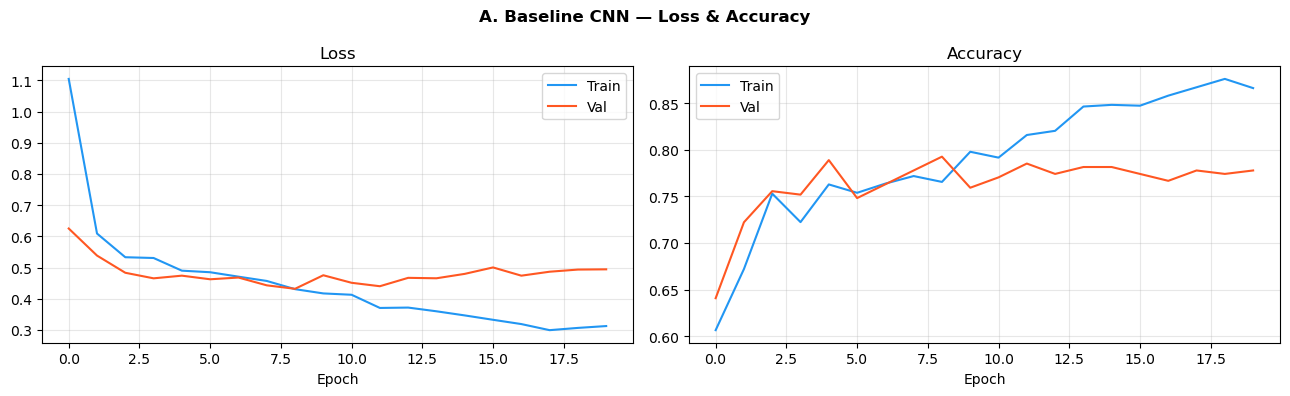


── Test Results ──
              precision    recall  f1-score   support

       Awake       0.77      0.77      0.77       133
       Sleep       0.80      0.80      0.80       147

    accuracy                           0.79       280
   macro avg       0.79      0.79      0.79       280
weighted avg       0.79      0.79      0.79       280

ROC-AUC : 0.8611


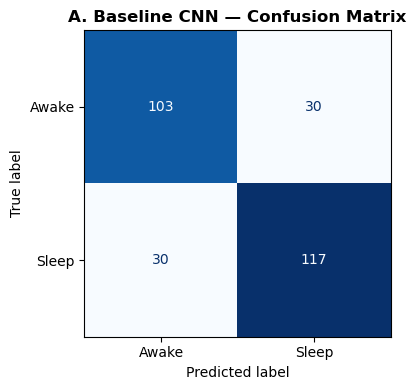

In [34]:
print('=' * 55)
print('  A. TRAINING BASELINE CNN')
print('=' * 55)
hist_base = train_model(baseline, train_loader, val_loader, tag='Baseline')
plot_history(hist_base, 'A. Baseline CNN — Loss & Accuracy')

y_true, y_pred, y_prob = test_model(baseline, test_loader)
print('\n── Test Results ──')
print(classification_report(y_true, y_pred, target_names=['Awake', 'Sleep']))
print(f'ROC-AUC : {roc_auc_score(y_true, y_prob):.4f}')
show_cm(y_true, y_pred, 'A. Baseline CNN — Confusion Matrix')

---
## B. CNN Component Experiments

One component is changed at a time; everything else stays identical to the baseline.

| # | What changes | Expected effect |
|---|---|---|
| B1 | Kernel 3×3 → **5×5** | Larger receptive field, more params, slower |
| B2 | Stride 1+MaxPool → **Stride 2, no pool** | Learned downsampling, same spatial reduction |
| B3 | Filters 32/64/128 → **16/32/64** (half) | Lower capacity, less overfitting, faster |
| B4 | MaxPool → **AvgPool** | Smoother activations, less peak preservation |
| B5 | 3 blocks → **5 blocks** (deeper) | Higher capacity, potential overfit / vanishing grad |

Kernel-5 params : 2,367,394
Baseline params : 2,195,362
[Kernel5] Ep 01/20  TrLoss=1.2901  TrAcc=0.562  VaLoss=0.6411  VaAcc=0.659  t=24.4s
[Kernel5] Ep 05/20  TrLoss=0.5960  TrAcc=0.664  VaLoss=0.5664  VaAcc=0.733  t=14.1s
[Kernel5] Ep 10/20  TrLoss=0.5090  TrAcc=0.730  VaLoss=0.4766  VaAcc=0.763  t=16.0s
[Kernel5] Ep 15/20  TrLoss=0.4524  TrAcc=0.779  VaLoss=0.4841  VaAcc=0.756  t=19.8s
[Kernel5] Ep 20/20  TrLoss=0.4234  TrAcc=0.788  VaLoss=0.4597  VaAcc=0.752  t=14.1s


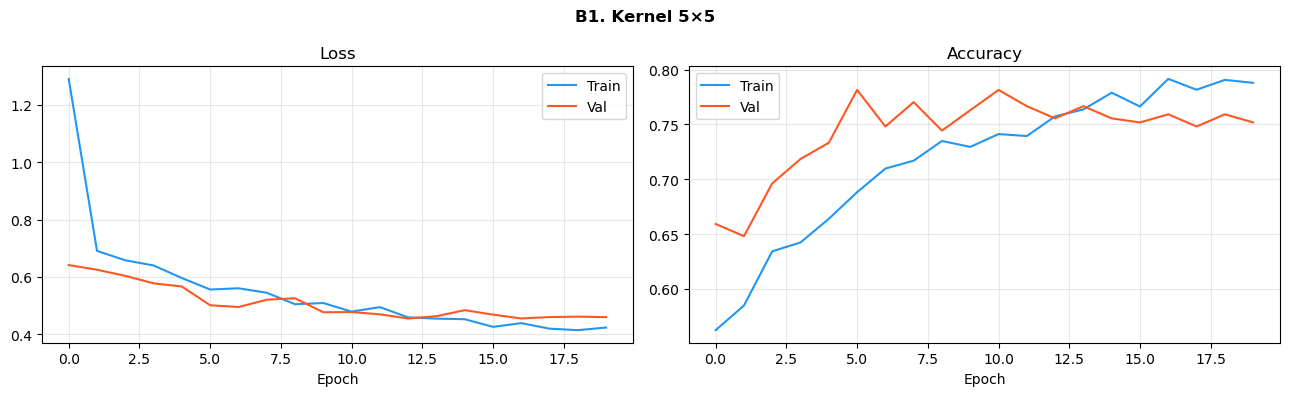

In [ ]:
# B1. Kernel Size 5×5
class CNN_Kernel5(nn.Module):
    def __init__(self, in_ch=16, nc=2):  # ← Change 1 → 16
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64,  kernel_size=5, padding=2),
            nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
        )
        
        # Recalculate flattened size: 128 × (64/8) × (64/8) = 128 × 8 × 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),  # This is correct for 64×64 input
            nn.ReLU(True), 
            nn.Dropout(0.5),
            nn.Linear(256, nc)
        )
    
    def forward(self, x): 
        return self.classifier(self.features(x))

# Create model with correct input channels
m_k5 = CNN_Kernel5(in_ch=16).to(DEVICE)  # ← Explicitly set in_ch=16
print(f'Kernel-5 params : {count_params(m_k5):,}')
print(f'Baseline params : {count_params(baseline):,}')
hist_k5 = train_model(m_k5, train_ldr, val_ldr, tag='Kernel5')
plot_history(hist_k5, 'B1. Kernel 5×5')

--- 

- Receptive field: Each 5×5 filter 'sees' a 5-pixel window vs 3 for the
  baseline.  Two stacked 5×5 convolutions equal a 9-pixel receptive field
  vs 5 for 3×3 — useful if discriminative patterns (**slow-wave bursts**)
  span wide frequency/time extents in the spectrogram.

- Model capacity: MORE — a 5×5 kernel has 25 weights vs 9, so each layer has
  25/9 ≈ 2.8× more filter parameters.

- Overfitting: Higher risk on small EEG datasets.  BN + Dropout partially
  compensate.

- Training time: SLOWER — larger kernels mean more multiply-accumulate ops
  per activation map.
---

Stride-2 params : 2,195,362
[Stride2] Ep 01/20  TrLoss=0.8025  TrAcc=0.638  VaLoss=0.5398  VaAcc=0.719  t=6.4s
[Stride2] Ep 05/20  TrLoss=0.4759  TrAcc=0.765  VaLoss=0.4662  VaAcc=0.796  t=5.6s
[Stride2] Ep 10/20  TrLoss=0.3712  TrAcc=0.824  VaLoss=0.4977  VaAcc=0.800  t=5.9s
[Stride2] Ep 15/20  TrLoss=0.2501  TrAcc=0.889  VaLoss=0.6037  VaAcc=0.752  t=5.9s
[Stride2] Ep 20/20  TrLoss=0.2053  TrAcc=0.925  VaLoss=0.6293  VaAcc=0.763  t=6.3s


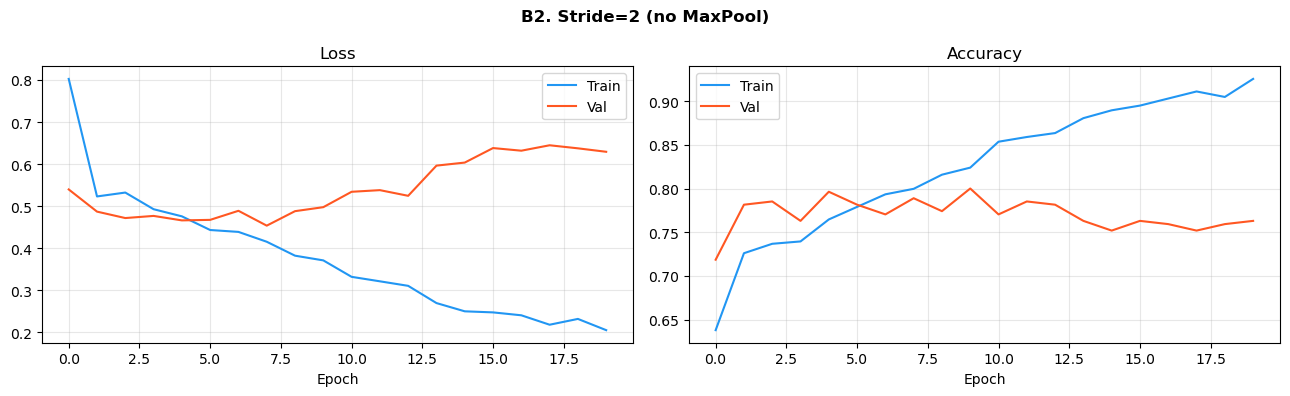

In [ ]:
# B2. Stride=2 (replaces MaxPool)
class CNN_Stride2(nn.Module):
    def __init__(self, in_ch=16, nc=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 64,  3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(True),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(256, nc)
        )
    def forward(self, x): return self.classifier(self.features(x))

m_s2 = CNN_Stride2(in_ch=16).to(DEVICE)
print(f'Stride-2 params : {count_params(m_s2):,}')
hist_s2 = train_model(m_s2, train_ldr, val_ldr, tag='Stride2')
plot_history(hist_s2, 'B2. Stride=2 (no MaxPool)')


---
Effect analysis
- Strided convolutions learn *how* to downsample, rather than always
  discarding the non-maximum value.  This can preserve richer structural
  information than MaxPool's hard selection rule.

- Model capacity: SIMILAR to baseline (same filter counts).

- Overfitting: Slightly lower risk because no extra parameters are added, but
  the learned downsampling adapts to the data.

- Training time: Comparable — same parameter count, stride ops are efficient.

- Performance: Often marginally better on recognition tasks; may be slightly
  worse if MaxPool is important **sharp delta-band**
  peaks in sleep spectrograms.
  
---


FewFilters params : 550,354
[FewFilters] Ep 01/20  TrLoss=0.7482  TrAcc=0.600  VaLoss=0.5973  VaAcc=0.730  t=6.9s
[FewFilters] Ep 05/20  TrLoss=0.5295  TrAcc=0.722  VaLoss=0.4611  VaAcc=0.800  t=6.4s
[FewFilters] Ep 10/20  TrLoss=0.4581  TrAcc=0.769  VaLoss=0.4645  VaAcc=0.781  t=6.4s
[FewFilters] Ep 15/20  TrLoss=0.3888  TrAcc=0.805  VaLoss=0.4638  VaAcc=0.785  t=6.6s
[FewFilters] Ep 20/20  TrLoss=0.3836  TrAcc=0.810  VaLoss=0.4741  VaAcc=0.800  t=17.9s


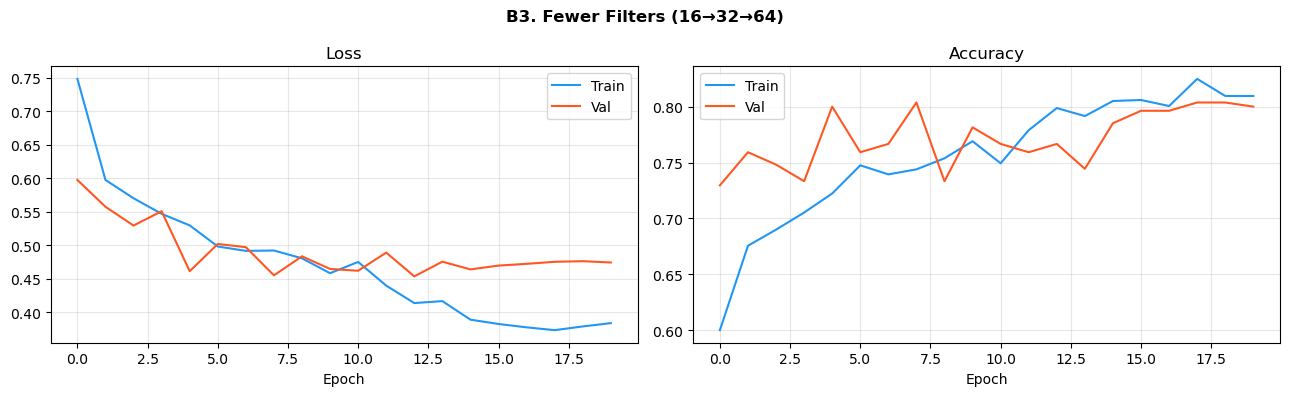

In [ ]:
# ────────────────────────────────────────────────────────────────
# B3. Fewer Filters — 16 / 32 / 64  (halved)
# ────────────────────────────────────────────────────────────────

class CNN_FewFilters(nn.Module):
    def __init__(self, in_ch=16, nc=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 16, 3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(128, nc)
        )
    def forward(self, x): return self.classifier(self.features(x))

m_ff = CNN_FewFilters().to(DEVICE)
print(f'FewFilters params : {count_params(m_ff):,}')
hist_ff = train_model(m_ff, train_ldr, val_ldr, tag='FewFilters')
plot_history(hist_ff, 'B3. Fewer Filters (16→32→64)')

---
Effect analysis

Number of filters = number of distinct features learned per layer.
  Halving filters roughly quarters conv-layer parameter counts (k² × Cin × Cout).

Model capacity: LOWER — the network can represent fewer feature channels.

Overfitting: REDUCED — fewer parameters means less risk of memorising noise.
  On small datasets this can actually *improve* generalisation (val accuracy).

Training time: FASTER — fewer multiply-accumulate ops.

Risk: Underfitting if the task requires many diverse features.  For the
  binary sleep/awake task, 16→32→64 is often sufficient.

---

[AvgPool2] Ep 01/20  TrLoss=0.7666  TrAcc=0.595  VaLoss=0.5623  VaAcc=0.763  t=10.8s
[AvgPool2] Ep 05/20  TrLoss=0.5072  TrAcc=0.731  VaLoss=0.5237  VaAcc=0.700  t=43.5s
[AvgPool2] Ep 10/20  TrLoss=0.4524  TrAcc=0.759  VaLoss=0.4855  VaAcc=0.752  t=31.5s
[AvgPool2] Ep 15/20  TrLoss=0.3861  TrAcc=0.819  VaLoss=0.4961  VaAcc=0.774  t=29.9s
[AvgPool2] Ep 20/20  TrLoss=0.3633  TrAcc=0.814  VaLoss=0.5044  VaAcc=0.763  t=29.3s
[AvgPool4] Ep 01/20  TrLoss=0.6727  TrAcc=0.614  VaLoss=0.5419  VaAcc=0.733  t=27.6s
[AvgPool4] Ep 05/20  TrLoss=0.5117  TrAcc=0.728  VaLoss=0.5116  VaAcc=0.730  t=26.7s
[AvgPool4] Ep 10/20  TrLoss=0.4476  TrAcc=0.783  VaLoss=0.4938  VaAcc=0.756  t=26.9s
[AvgPool4] Ep 15/20  TrLoss=0.3941  TrAcc=0.796  VaLoss=0.4870  VaAcc=0.744  t=13.8s
[AvgPool4] Ep 20/20  TrLoss=0.3623  TrAcc=0.826  VaLoss=0.4891  VaAcc=0.759  t=13.5s


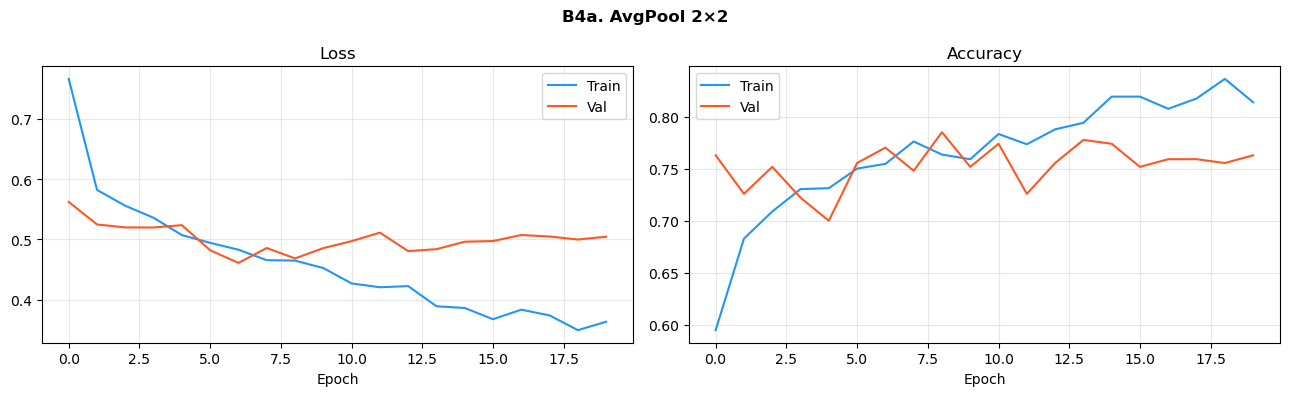

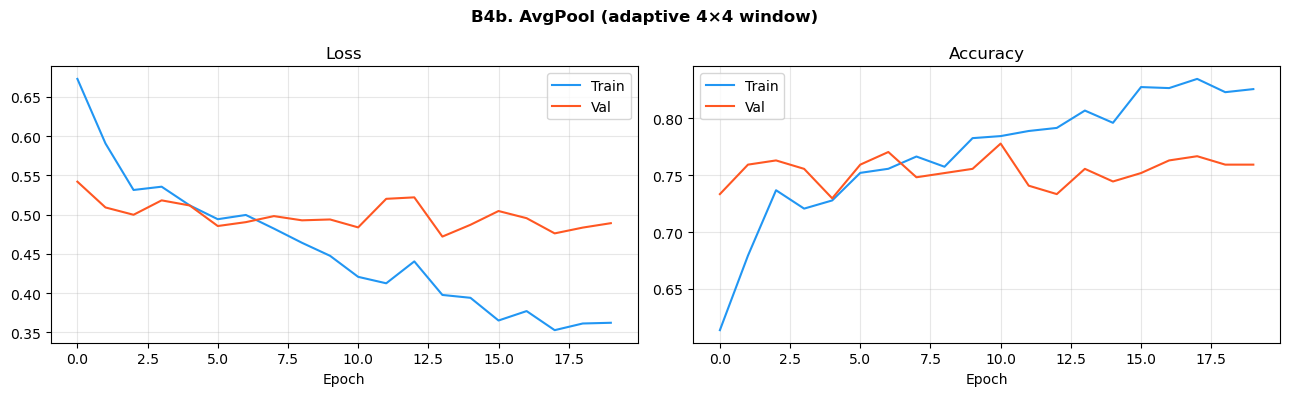

In [ ]:

# B4a. AvgPool 2×2  vs  B4b. AvgPool 4×4 (larger window)

def make_pool_cnn(pool_layer):
    class _CNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(16, 32, 3, padding=1),
                nn.BatchNorm2d(32), nn.ReLU(True), pool_layer,
                nn.Conv2d(32, 64, 3, padding=1),
                nn.BatchNorm2d(64), nn.ReLU(True), pool_layer,
                nn.Conv2d(64, 128, 3, padding=1),
                nn.BatchNorm2d(128), nn.ReLU(True), pool_layer,
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128 * 8 * 8, 256), nn.ReLU(True), nn.Dropout(0.5),
                nn.Linear(256, 2)
            )
        def forward(self, x): return self.classifier(self.features(x))
    return _CNN()

# Note: pooling layers are NOT shared state in Sequential, pass fresh instances
m_ap2 = make_pool_cnn(nn.AvgPool2d(2)).to(DEVICE)
m_ap4 = make_pool_cnn(nn.AvgPool2d(4)).to(DEVICE)  # 64→16→4→1 — use AdaptiveAvgPool to keep spatial dims

# Safer version for AvgPool(4) to avoid spatial collapse
class CNN_AvgPool4(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(True), nn.AvgPool2d(2),  # 64→32
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(True), nn.AvgPool2d(2),  # 32→16
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(4),                              # → 4×4 (window≈4)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(256, 2)
        )
    def forward(self, x): return self.classifier(self.features(x))

m_ap2 = make_pool_cnn(nn.AvgPool2d(2)).to(DEVICE)
m_ap4 = CNN_AvgPool4().to(DEVICE)

hist_ap2 = train_model(m_ap2, train_ldr, val_ldr, tag='AvgPool2')
hist_ap4 = train_model(m_ap4, train_ldr, val_ldr, tag='AvgPool4')
plot_history(hist_ap2, 'B4a. AvgPool 2×2')
plot_history(hist_ap4, 'B4b. AvgPool (adaptive 4×4 window)')

---
Effect analysis

MaxPool retains the maximum activation in each window → preserves strong
  local features, good for detecting sharp spectral peaks (**sleep spindles,
  K-complexes, delta waves**).

AvgPool(2×2) smooths activations → averages out noise but also blurs peaks.
  **Useful when the overall energy distribution matters more than peak location.**

AvgPool(4×4) applies even stronger smoothing — aggressive spatial compression
  loses fine-grained frequency structure and usually hurts performance on
  spectrogram tasks.

Model capacity: Pooling layers have NO learnable parameters — the difference
  is purely in information selection strategy.

Training time: Negligible difference.

Overfitting: AvgPool can act as mild regularisation by smoothing gradients.


----

Deep-5 params : 3,082,402
[Deep5] Ep 01/20  TrLoss=0.8596  TrAcc=0.520  VaLoss=0.6985  VaAcc=0.489  t=25.8s
[Deep5] Ep 05/20  TrLoss=0.5715  TrAcc=0.695  VaLoss=0.5128  VaAcc=0.756  t=25.0s
[Deep5] Ep 10/20  TrLoss=0.4419  TrAcc=0.775  VaLoss=0.4864  VaAcc=0.715  t=53.4s
[Deep5] Ep 15/20  TrLoss=0.3791  TrAcc=0.814  VaLoss=0.5230  VaAcc=0.730  t=60.4s
[Deep5] Ep 20/20  TrLoss=0.3529  TrAcc=0.836  VaLoss=0.5512  VaAcc=0.741  t=60.4s


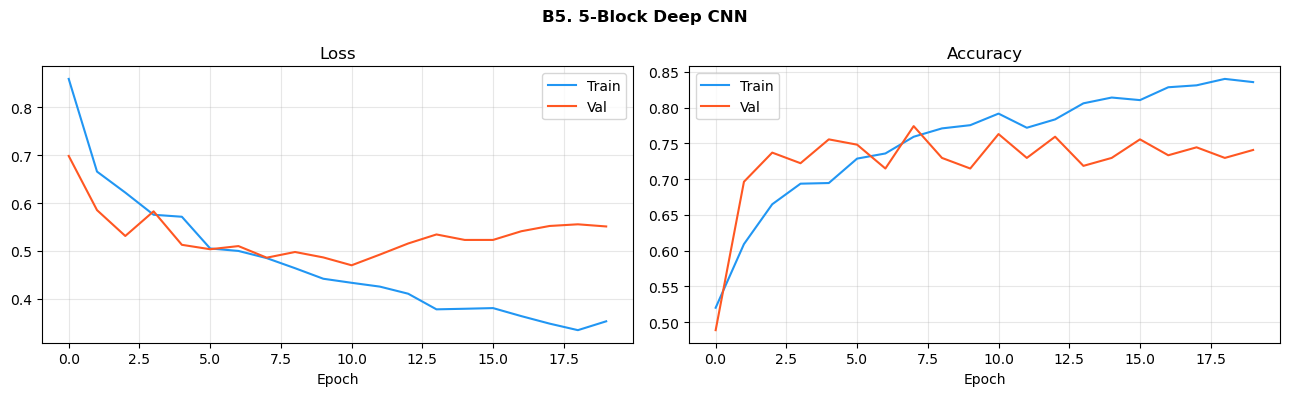

In [ ]:

# B5. Deeper Network — 5 Conv Blocks


class CNN_Deep5(nn.Module):
    def __init__(self, in_ch=16, nc=2):
        super().__init__()

        def conv_block(ci, co, pool=True):
            layers = [
                nn.Conv2d(ci, co, 3, padding=1),
                nn.BatchNorm2d(co),
                nn.ReLU(True),
            ]
            if pool: layers.append(nn.MaxPool2d(2))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            conv_block(in_ch, 32,  pool=True),   # 64→32
            conv_block(32,    64,  pool=True),   # 32→16
            conv_block(64,   128,  pool=True),   # 16→8
            conv_block(128,  256,  pool=False),  # 8→8  (no pool)
            conv_block(256,  256,  pool=False),  # 8→8  (no pool)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(4),  # → 4×4
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(512, nc)
        )

    def forward(self, x): return self.classifier(self.features(x))

m_d5 = CNN_Deep5().to(DEVICE)
print(f'Deep-5 params : {count_params(m_d5):,}')
hist_d5 = train_model(m_d5, train_ldr, val_ldr, tag='Deep5')
plot_history(hist_d5, 'B5. 5-Block Deep CNN')


---
Effect analysis

Depth allows the network to build a hierarchy of increasingly abstract
  representations: low-level (edges) → mid-level (texture patterns) →
  high-level (sleep spindle / delta rhythm morphology).

Model capacity: HIGHER — more parameters AND more composition steps.

Overfitting: HIGH risk on small biomedical datasets without skip connections
  (ResNet-style).  We mitigate with BN + Dropout.

Vanishing gradients: An issue without BN; BatchNorm normalises each layer's
  activations and stabilises gradient flow.

Training time: SLOWER — more sequential operations.

Spatial resolution: With 64×64 input and MaxPool×3, spatial dims reach
  8×8.  Blocks 4–5 use no additional pooling to avoid collapse to 1×1.

---



=== B. Component Experiment Summary ===
                     Model    Params Best Val Acc Final Tr Acc Overfit Gap Avg Ep (s)
A. Baseline (3×3, MaxPool) 2,195,362       0.7926       0.8661      0.0735        9.6
            B1. Kernel 5×5 2,367,394       0.7815       0.7880      0.0065       21.3
              B2. Stride=2 2,195,362       0.8000       0.9254      0.1254        6.0
  B3. Few Filters 16/32/64   550,354       0.8037       0.8095      0.0058        7.1
          B4a. AvgPool 2×2 2,195,362       0.7852       0.8140      0.0288       30.4
          B4b. AvgPool 4×4   622,498       0.7778       0.8257      0.0479      115.1
       B5. Deep (5 blocks) 3,082,402       0.7741       0.8356      0.0615       60.8


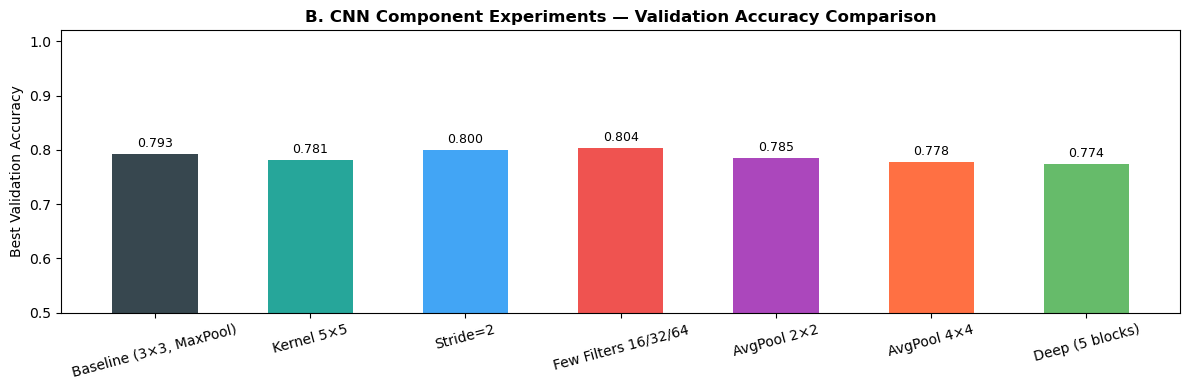

In [46]:
# ── Summary Table & Bar Chart ─────────────────────────────────────────────────
experiments = [
    ('A. Baseline (3×3, MaxPool)', baseline, hist_base),
    ('B1. Kernel 5×5',             m_k5,     hist_k5),
    ('B2. Stride=2',               m_s2,     hist_s2),
    ('B3. Few Filters 16/32/64',   m_ff,     hist_ff),
    ('B4a. AvgPool 2×2',           m_ap2,    hist_ap2),
    ('B4b. AvgPool 4×4',           m_ap4,    hist_ap4),
    ('B5. Deep (5 blocks)',         m_d5,     hist_d5),
]

rows = []
for name, model, hist in experiments:
    rows.append({
        'Model':         name,
        'Params':        f"{count_params(model):,}",
        'Best Val Acc':  f"{max(hist['va_acc']):.4f}",
        'Final Tr Acc':  f"{hist['tr_acc'][-1]:.4f}",
        'Overfit Gap':   f"{hist['tr_acc'][-1] - max(hist['va_acc']):.4f}",
        'Avg Ep (s)':    f"{np.mean(hist['epoch_sec']):.1f}",
    })

df = pd.DataFrame(rows)
print('\n=== B. Component Experiment Summary ===')
print(df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
names = [r['Model'].split('.')[1].strip() if '.' in r['Model'] else r['Model']
         for r in rows]
accs  = [float(r['Best Val Acc']) for r in rows]
colors = ['#37474F'] + ['#26A69A','#42A5F5','#EF5350','#AB47BC','#FF7043','#66BB6A']
bars = ax.bar(names, accs, color=colors[:len(names)], width=0.55)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_ylim(0.5, 1.02); ax.set_ylabel('Best Validation Accuracy')
ax.set_title('B. CNN Component Experiments — Validation Accuracy Comparison',
             fontweight='bold')
ax.tick_params(axis='x', labelrotation=15)
plt.tight_layout(); plt.show()

---
## C. Data Augmentation

Data augmentation artificially expands the training set by applying **random, label-preserving transformations**, forcing the CNN to learn features that are invariant to those transformations.

**Techniques applied:**

| Technique | Rationale for EEG spectrograms |
|-----------|-------------------------------|
| `RandomHorizontalFlip` | Time-reversal symmetry of wake/sleep features |
| `RandomRotation(±10°)` | Slight misalignment robustness |
| `RandomCrop(64, pad=6)` | Simulates electrode placement variation |
| `ColorJitter(brightness, contrast)` | Amplitude scale invariance |
| `RandomErasing(p=0.2)` | Dropout in pixel space; simulates signal dropout |
| `Normalize(0.5, 0.5)` | Always applied — zero-centres gradients |

**Effect on overfitting & generalisation:**  
Augmentation widens the distribution of training samples, so the model cannot memorise exact spectrogram patterns.  The gap between training accuracy and validation accuracy should narrow — a direct measure of reduced overfitting.  The improvement is most pronounced when the dataset is small (a common scenario in medical/EEG research).

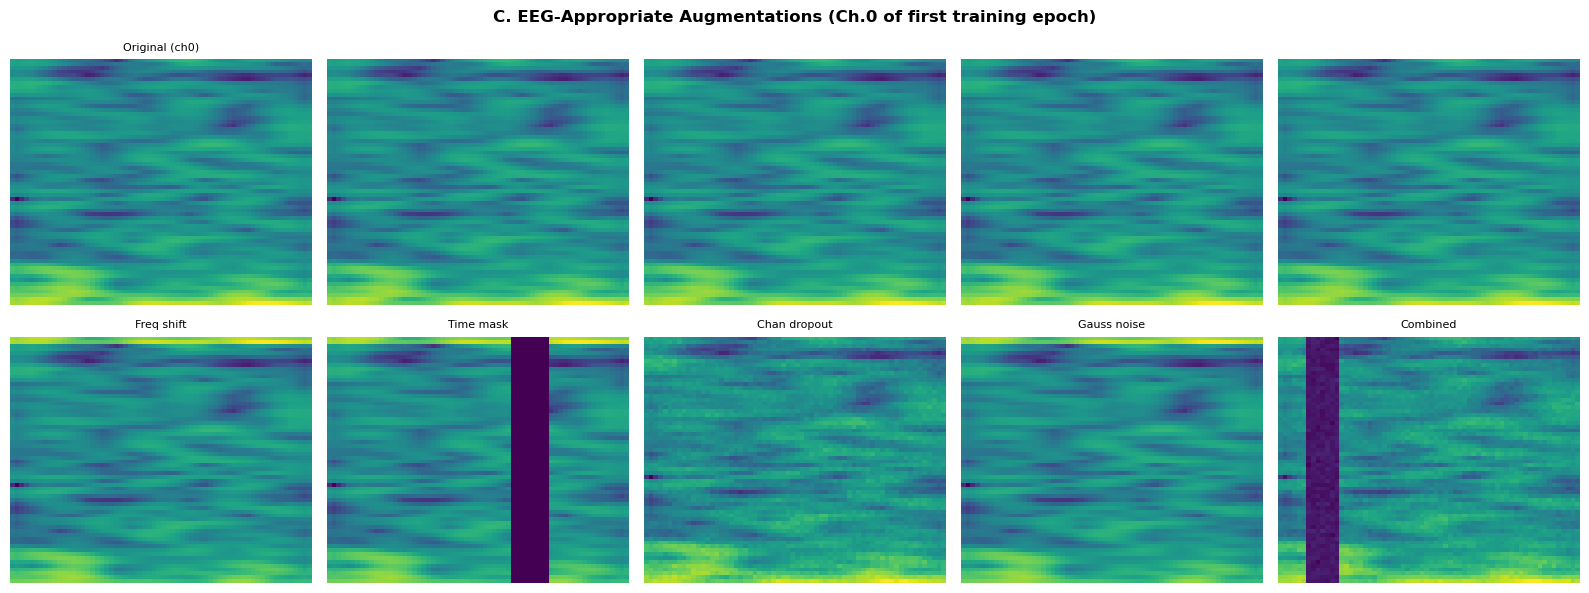

=== C. Training Baseline CNN WITH EEG Augmentation ===
[Augmented] Ep 01/20  TrLoss=1.3094  TrAcc=0.544  VaLoss=0.6044  VaAcc=0.711  t=25.1s
[Augmented] Ep 05/20  TrLoss=0.5913  TrAcc=0.684  VaLoss=0.5106  VaAcc=0.756  t=15.5s
[Augmented] Ep 10/20  TrLoss=0.4717  TrAcc=0.750  VaLoss=0.4662  VaAcc=0.774  t=33.1s
[Augmented] Ep 15/20  TrLoss=0.4084  TrAcc=0.800  VaLoss=0.4661  VaAcc=0.752  t=33.7s
[Augmented] Ep 20/20  TrLoss=0.3959  TrAcc=0.813  VaLoss=0.4541  VaAcc=0.778  t=23.1s


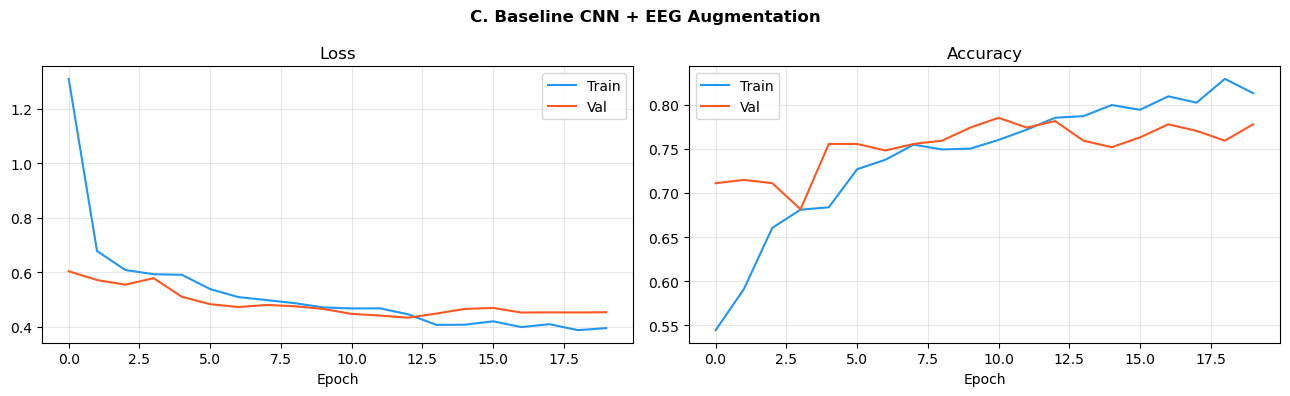


Overfit gap WITHOUT augmentation : 0.0735
Overfit gap WITH    augmentation : 0.0279
→ Augmentation REDUCED overfitting

── Augmented Model — Test Report ──
              precision    recall  f1-score   support

       Awake       0.76      0.77      0.76       133
       Sleep       0.79      0.78      0.78       147

    accuracy                           0.78       280
   macro avg       0.77      0.77      0.77       280
weighted avg       0.78      0.78      0.78       280



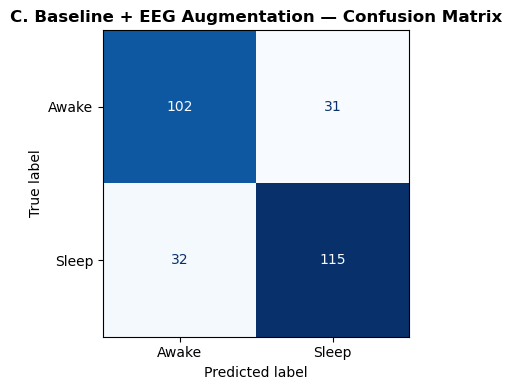

In [ ]:

sample_idx = np.where(y_train == 0)[0][0]
orig_spec   = torch.from_numpy(X_train[sample_idx]).float()  

fig, axes = plt.subplots(2, 5, figsize=(16, 6))

def show_spec(ax, t, title):
    ax.imshow(t[0].numpy(), aspect='auto', origin='lower', cmap='viridis')
    ax.set_title(title, fontsize=8); ax.axis('off')


for col in range(5):
    show_spec(axes[0, col], orig_spec, f'Original (ch0)' if col==0 else '')
aug_names = ['Freq shift', 'Time mask', 'Chan dropout', 'Gauss noise', 'Combined']
aug_ds_preview = EEGMelDataset(X_train[:20], y_train[:20], augment=True)
for col in range(5):
    aug_x, _ = aug_ds_preview[0]     # triggers augmentation
    aug_x = (aug_x + 1) / 2          # un-normalise for display
    show_spec(axes[1, col], aug_x, aug_names[col])

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('Augmented', fontsize=10)
plt.suptitle('C. EEG-Appropriate Augmentations (Ch.0 of first training epoch)',
             fontweight='bold')
plt.tight_layout(); plt.show()

#Training with augmentation (already on by default via augment=True in train_ds) ─
baseline_aug = BaselineCNN(in_ch=N_INPUT_CH).to(DEVICE)
print('=== C. Training Baseline CNN WITH EEG Augmentation ===')
hist_aug = train_model(baseline_aug, train_ldr, val_ldr, tag='Augmented')
plot_history(hist_aug, 'C. Baseline CNN + EEG Augmentation')

gap_base = hist_base['tr_acc'][-1] - max(hist_base['va_acc'])
gap_aug  = hist_aug['tr_acc'][-1]  - max(hist_aug['va_acc'])
print(f'\nOverfit gap WITHOUT augmentation : {gap_base:.4f}')
print(f'Overfit gap WITH    augmentation : {gap_aug:.4f}')
print('→ Augmentation', 'REDUCED' if gap_aug < gap_base else 'did NOT reduce', 'overfitting')

y_ta, y_pa, _ = test_model(baseline_aug, test_ldr)
print('\n── Augmented Model — Test Report ──')
print(classification_report(y_ta, y_pa, target_names=['Awake', 'Sleep']))
show_cm(y_ta, y_pa, 'C. Baseline + EEG Augmentation — Confusion Matrix')


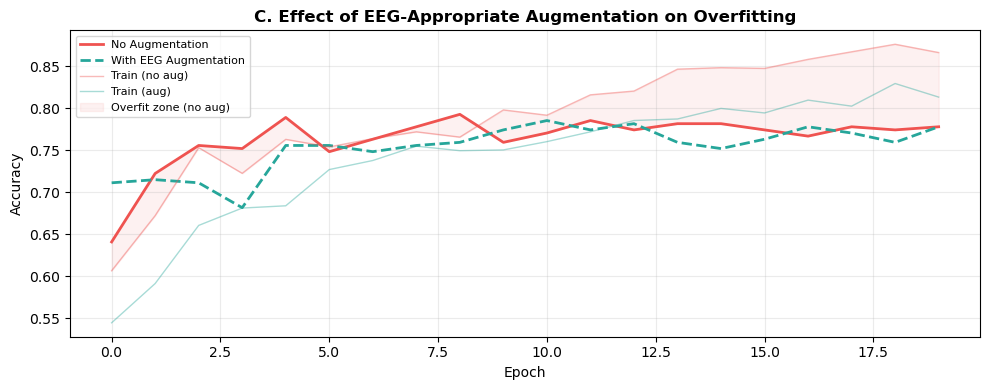

In [50]:
# Side-by-side: val accuracy without vs with EEG augmentation
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_base['va_acc'], label='No Augmentation', lw=2, color='#EF5350')
ax.plot(hist_aug['va_acc'],  label='With EEG Augmentation', lw=2,
        color='#26A69A', linestyle='--')
ax.plot(hist_base['tr_acc'], label='Train (no aug)',   lw=1, color='#EF5350', alpha=0.4)
ax.plot(hist_aug['tr_acc'],  label='Train (aug)',      lw=1, color='#26A69A', alpha=0.4)
ax.fill_between(range(EPOCHS),
                hist_base['tr_acc'], hist_base['va_acc'],
                alpha=0.08, color='#EF5350', label='Overfit zone (no aug)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_title('C. Effect of EEG-Appropriate Augmentation on Overfitting', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()


## What if we combine two models with differenet parameters ?

 **Multi‑branch idea**
The  idea can be seen as a multi‑branch, multi‑kernel 1D‑CNN:

**Branch A**: specializes in slow waves

- Larger temporal kernels (e.g., 64–256 samples)

-Larger stride / more pooling

- Good for delta / slow oscillations and long bursts

**Branch B**: specializes in faster, sharper components

- Smaller kernels (e.g., 3–15 samples)

- Smaller stride / finer pooling

- Good for capturing sharp transients and higher frequency content

we then combine (weight) the outputs of these branches (e.g., via concatenation + dense layer, or via learned attention) for final classification. T

**The code will be uploaded soon**

---
## D. Transfer Learning — MobileNetV2

### Choice: MobileNetV2

**Why MobileNetV2?**
- Compact (~3.5 M parameters) — avoids over-parameterisation on a small EEG dataset.
- Pre-trained on **ImageNet** — rich low-level features (Gabor-like edges, texture detectors) that transfer well to spectrogram images.
- Uses **inverted residual blocks with linear bottlenecks** — excellent gradient flow during fine-tuning.
- Faster than VGG19 or ResNet50, suitable for iterative experiments.

### Strategy A — Feature Extraction
- **All backbone layers frozen.**  Only the custom 2-class head is trainable.
- The frozen backbone acts as a fixed feature extractor.
- Fast, low overfitting risk, but constrained by ImageNet features.

### Strategy B — Partial Fine-Tuning
- **Layers 0–13 frozen** (early generic features: edges, textures).
- **Layers 14–18 + classifier unfrozen** (deeper, more domain-specific features adapted to EEG spectrograms).
- Better domain adaptation at cost of slightly higher overfitting risk.

In [ ]:
# ── MobileNetV2 transfer learning — multi-channel → 3-channel adapter ────────
# MobileNetV2 expects (batch, 3, H, W).
# Strategy: reduce our N_INPUT_CH channels to 3 via a learned 1×1 conv adapter
# placed BEFORE the frozen backbone. This is better than just taking 3 channels.

class ChannelAdapter(nn.Module):
    """Learned 1×1 conv that maps N_INPUT_CH → 3 channels."""
    def __init__(self, in_ch, out_ch=3):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        nn.init.xavier_uniform_(self.conv.weight)
    def forward(self, x):
        return self.conv(x)

# Normalise to ImageNet 
imagenet_norm = T.Normalize(mean=[0.485, 0.456, 0.406],
                             std= [0.229, 0.224, 0.225])

class AdaptedMobileNet(nn.Module):
    """MobileNetV2 with a learnable channel adapter prepended."""
    def __init__(self, in_ch, backbone, freeze_backbone=True):
        super().__init__()
        self.adapter  = ChannelAdapter(in_ch, out_ch=3)
        self.backbone = backbone
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x):
        # x: (B, C, H, W) already normalised to [-1,1]
        # un-normalise to [0,1], apply adapter, re-normalise to ImageNet stats
        x = (x + 1) / 2                          # [-1,1] → [0,1]
        x = self.adapter(x)                       # → (B, 3, H, W)
        # per-channel ImageNet normalisation
        mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1,3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1,3,1,1)
        x    = (x - mean) / std
        return self.backbone(x)

print(f'Transfer learning loaders: input {N_INPUT_CH} channels (adapter → 3 for MobileNet)')
rgb_tr_ldr, rgb_va_ldr, rgb_te_ldr = train_ldr, val_ldr, test_ldr
print('Loaders ready.')


Transfer learning loaders: input 16 channels (adapter → 3 for MobileNet)
Loaders ready.


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\rakyn/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:01<00:00, 8.39MB/s]


D1 Feature Extraction:
  Adapter (1×1 conv) : always trainable
  Backbone           : FROZEN
  Trainable params   : 48 / total: 2,226,482
[MobNet-FE] Ep 01/15  TrLoss=0.7442  TrAcc=0.528  VaLoss=0.6938  VaAcc=0.548  t=26.7s
[MobNet-FE] Ep 05/15  TrLoss=0.7498  TrAcc=0.506  VaLoss=0.6972  VaAcc=0.574  t=20.9s
[MobNet-FE] Ep 10/15  TrLoss=0.7746  TrAcc=0.500  VaLoss=0.7032  VaAcc=0.541  t=21.0s
[MobNet-FE] Ep 15/15  TrLoss=0.7532  TrAcc=0.508  VaLoss=0.6971  VaAcc=0.544  t=25.8s


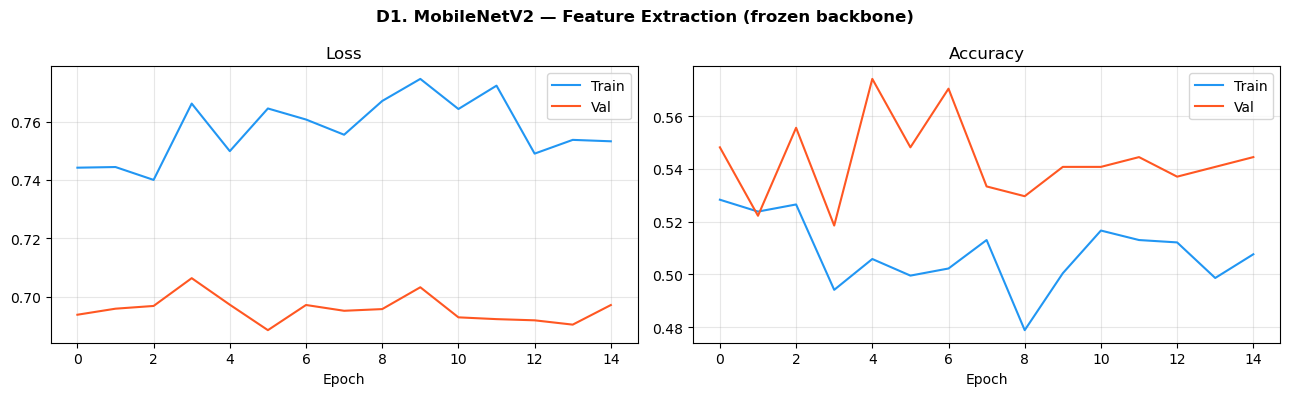

              precision    recall  f1-score   support

       Awake       0.53      0.44      0.48       133
       Sleep       0.56      0.65      0.60       147

    accuracy                           0.55       280
   macro avg       0.55      0.54      0.54       280
weighted avg       0.55      0.55      0.55       280



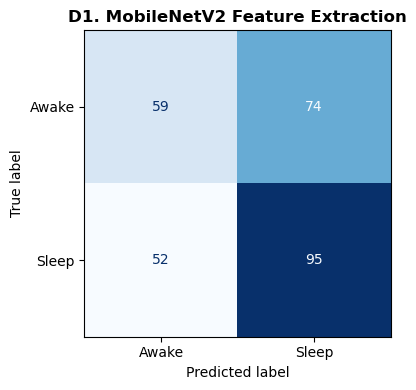

In [53]:
# ── D1. Feature Extraction (backbone frozen, only adapter + head trained) ─────
backbone_fe = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
backbone_fe.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(backbone_fe.last_channel, 2),
)

mob_fe = AdaptedMobileNet(in_ch=N_INPUT_CH, backbone=backbone_fe,
                           freeze_backbone=True).to(DEVICE)

trainable = count_params(mob_fe)
total     = sum(p.numel() for p in mob_fe.parameters())
print(f'D1 Feature Extraction:')
print(f'  Adapter (1×1 conv) : always trainable')
print(f'  Backbone           : FROZEN')
print(f'  Trainable params   : {trainable:,} / total: {total:,}')

hist_fe = train_model(mob_fe, rgb_tr_ldr, rgb_va_ldr,
                      epochs=15, lr=5e-4, tag='MobNet-FE')
plot_history(hist_fe, 'D1. MobileNetV2 — Feature Extraction (frozen backbone)')

y_tfe, y_pfe, _ = test_model(mob_fe, rgb_te_ldr)
print(classification_report(y_tfe, y_pfe, target_names=['Awake', 'Sleep']))
show_cm(y_tfe, y_pfe, 'D1. MobileNetV2 Feature Extraction')


D2 Partial Fine-Tuning:
  Adapter            : trainable
  Backbone[0..13]    : FROZEN
  Backbone[14..18]   : trainable
  Classifier         : trainable
  Trainable params   : 1,683,954 / total: 2,226,482
[MobNet-FT] Ep 01/15  TrLoss=0.6437  TrAcc=0.619  VaLoss=0.7125  VaAcc=0.581  t=18.8s
[MobNet-FT] Ep 05/15  TrLoss=0.6561  TrAcc=0.608  VaLoss=0.6420  VaAcc=0.622  t=11.8s
[MobNet-FT] Ep 10/15  TrLoss=0.6456  TrAcc=0.628  VaLoss=0.6375  VaAcc=0.622  t=16.5s
[MobNet-FT] Ep 15/15  TrLoss=0.6509  TrAcc=0.615  VaLoss=0.6243  VaAcc=0.644  t=32.3s


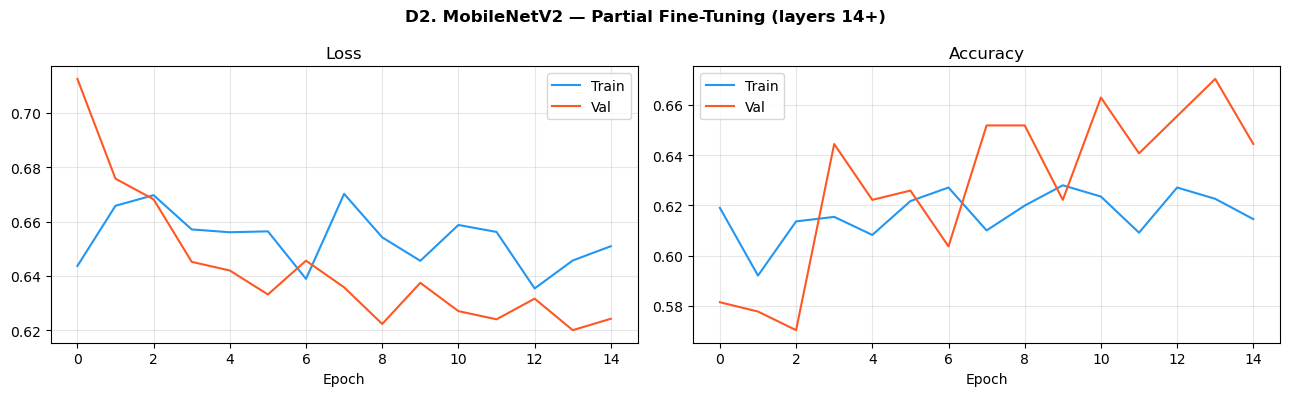

              precision    recall  f1-score   support

       Awake       0.63      0.44      0.52       133
       Sleep       0.60      0.76      0.67       147

    accuracy                           0.61       280
   macro avg       0.61      0.60      0.60       280
weighted avg       0.61      0.61      0.60       280



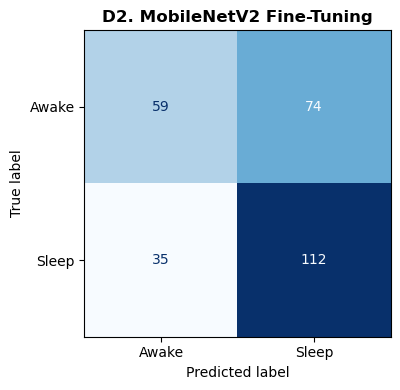

In [54]:
# ── D2. Partial Fine-Tuning (adapter + features[14+] + classifier unfrozen) ───
backbone_ft = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
backbone_ft.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(backbone_ft.last_channel, 2),
)

mob_ft = AdaptedMobileNet(in_ch=N_INPUT_CH, backbone=backbone_ft,
                           freeze_backbone=True).to(DEVICE)

# Selectively unfreeze backbone features[14+]
for name, param in mob_ft.backbone.named_parameters():
    if name.startswith('features'):
        try:
            layer_num = int(name.split('.')[1])
            param.requires_grad = (layer_num >= 14)
        except ValueError:
            param.requires_grad = False
    else:
        param.requires_grad = True   # classifier head always unfrozen

trainable_ft = count_params(mob_ft)
total_ft     = sum(p.numel() for p in mob_ft.parameters())
print(f'D2 Partial Fine-Tuning:')
print(f'  Adapter            : trainable')
print(f'  Backbone[0..13]    : FROZEN')
print(f'  Backbone[14..18]   : trainable')
print(f'  Classifier         : trainable')
print(f'  Trainable params   : {trainable_ft:,} / total: {total_ft:,}')

hist_ft = train_model(mob_ft, rgb_tr_ldr, rgb_va_ldr,
                      epochs=15, lr=1e-4, tag='MobNet-FT')
plot_history(hist_ft, 'D2. MobileNetV2 — Partial Fine-Tuning (layers 14+)')

y_tft, y_pft, _ = test_model(mob_ft, rgb_te_ldr)
print(classification_report(y_tft, y_pft, target_names=['Awake', 'Sleep']))
show_cm(y_tft, y_pft, 'D2. MobileNetV2 Fine-Tuning')


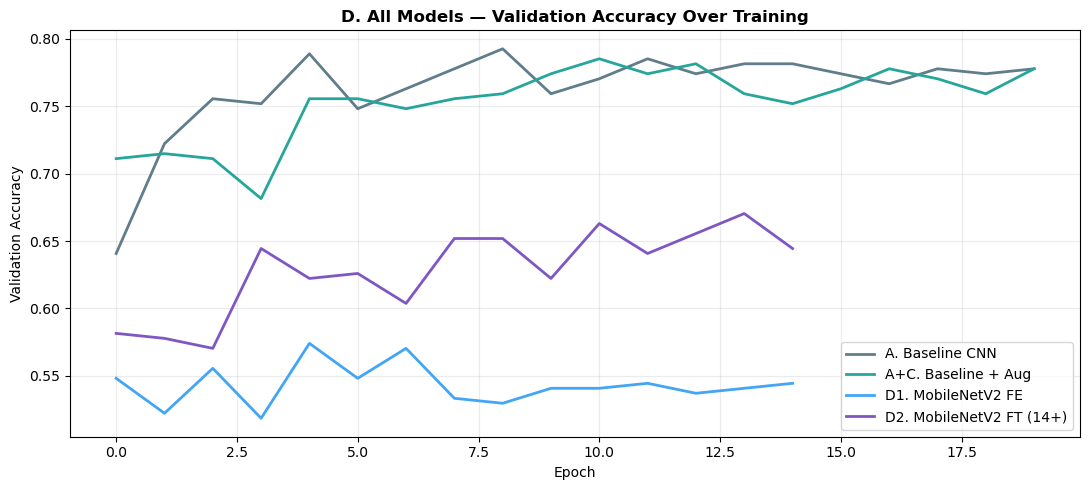


=== Final Performance Summary ===
  A. Baseline CNN                      Best Val Acc: 0.7926
  A+C. Baseline + Aug                  Best Val Acc: 0.7852
  D1. MobileNetV2 FE                   Best Val Acc: 0.5741
  D2. MobileNetV2 FT (14+)             Best Val Acc: 0.6704


In [55]:
# ── D3. Final Comparison ──────────────────────────────────────────────────────
compare = {
    'A. Baseline CNN':           hist_base,
    'A+C. Baseline + Aug':       hist_aug,
    'D1. MobileNetV2 FE':        hist_fe,
    'D2. MobileNetV2 FT (14+)':  hist_ft,
}
pal = ['#607D8B','#26A69A','#42A5F5','#7E57C2']

fig, ax = plt.subplots(figsize=(11, 5))
for (label, hist), c in zip(compare.items(), pal):
    ax.plot(hist['va_acc'], label=label, color=c, lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy')
ax.set_title('D. All Models — Validation Accuracy Over Training',
             fontweight='bold')
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print('\n=== Final Performance Summary ===')
for label, hist in compare.items():
    print(f'  {label:35s}  Best Val Acc: {max(hist["va_acc"]):.4f}')

## D.4 Why MobileNetV2 Transfer Learning Underperformed


- **Domain gap** — ImageNet features (fur, edges, colour) have no overlap with EEG Mel spectrograms (thin horizontal frequency bands) | Frozen features are semantically useless 
- **Spatial resolution** —`IMG_SIZE=64` vs MobileNetV2 optimal 224×224; depthwise strides collapse the spatial map to ~4×4 by layer  
**Key takeaway:** ImageNet pre-training helps when target images share *local feature statistics*
with natural photos (e.g. medical X-rays share edge/texture patterns). EEG spectrograms do not —
the patterns are long horizontal bands at fixed frequency positions, which no ImageNet image contains.
The right solution is a **domain-specific pre-trained backbone**, which is exactly what Section E introduces

**EEGNet** (Lawhern et al., 2018) is a compact CNN specifically designed for EEG classification.
Its depthwise separable convolutions first capture **temporal** frequency patterns and then
**spatial** inter-channel patterns — exactly the structure of our Mel spectrograms.

### Strategy

1. **E1 — EEGNet Feature Extractor**: Train a lightweight EEGNet-style encoder on the *full dataset*
  
2. **E2 — EEG Transformer**: Take the frozen EEGNet encoder's feature maps, feed them as a
   sequence of patch tokens into a Transformer encoder. The Transformer learns long-range
   temporal-frequency dependencies that the CNN cannot capture.
3. **E3 — Full fine-tuning**: Unfreeze the EEGNet backbone and jointly fine-tune
   EEGNet encoder + Transformer classifier end-to-end.

This mirrors the BERT → fine-tuning paradigm: domain-specific pre-training → Transformer fine-tuning.


code will be uploaded soon

In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# E1. EEGNet-style Encoder — domain-specific feature extractor
#
# Architecture follows Lawhern et al. (2018) adapted for Mel spectrogram input:
#   Block 1 — Temporal conv: captures frequency-band patterns (horizontal structure)
#   Block 2 — Depthwise spatial conv: captures inter-channel patterns
#   Block 3 — Separable conv: learns combined spatio-temporal features
#   Output   — compact feature vector per sample (used by Transformer in E2)
# ══════════════════════════════════════════════════════════════════════════════

import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, matplotlib.pyplot as plt
from torch.utils.data import DataLoader

class EEGNetEncoder(nn.Module):
    """
    EEGNet-inspired encoder for multi-channel Mel spectrograms.
    Input : (B, C, H, W)  — C=N_INPUT_CH, H=W=64
    Output: (B, embed_dim) feature vector
    """
    def __init__(self, in_ch=16, H=64, W=64, F1=8, D=2, F2=16, embed_dim=128, dropout=0.3):
        super().__init__()
        self.embed_dim = embed_dim

        # ── Block 1: Temporal convolution (along frequency axis = rows) ──────
        # Captures delta/theta/alpha/beta horizontal band structure
        self.temporal_conv = nn.Sequential(
            nn.Conv2d(in_ch, F1, kernel_size=(1, 25), padding=(0, 12), bias=False),
            nn.BatchNorm2d(F1),
        )

        # ── Block 2: Depthwise spatial convolution (across channels) ─────────
        # Captures inter-electrode spatial patterns
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(F1, F1 * D, kernel_size=(in_ch, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),
        )

        # ── Block 3: Separable convolution ───────────────────────────────────
        self.separable_conv = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, kernel_size=(1, 16), padding=(0, 8),
                      groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, kernel_size=1, bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout),
        )

        # ── Projection head → embed_dim ───────────────────────────────────────
        # Compute output size dynamically
        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, H, W)
            out = self._forward_features(dummy)
        flat_size = out.shape[1]
        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, embed_dim),
            nn.LayerNorm(embed_dim),
        )

    def _forward_features(self, x):
        x = self.temporal_conv(x)       # (B, F1, C, W)
        x = self.spatial_conv(x)         # (B, F1*D, 1, W//4)
        x = self.separable_conv(x)       # (B, F2, 1, W//32)
        return x.flatten(1)

    def forward(self, x):
        return self.projection(self._forward_features(x))

    def get_feature_map(self, x):
        """Return spatial feature map before projection (used by Transformer)."""
        x = self.temporal_conv(x)
        x = self.spatial_conv(x)
        x = self.separable_conv(x)       # (B, F2, 1, T)
        return x.squeeze(2)              # (B, F2, T) — sequence of T time frames


# ── Pre-train EEGNet encoder on a proxy task: band-power reconstruction ───────
# The proxy task forces the encoder to learn EEG-relevant features before
# we attach the Transformer head. This is the "pre-training" step.
# Proxy: predict the mean power in each of the 5 frequency bands per epoch.
# (5 bands × 1 value = 5-dim regression target — simple but domain-meaningful)

N_BANDS = 5  # delta, theta, alpha, beta, gamma

class EEGNetPretrainer(nn.Module):
    """EEGNet encoder + band-power regression head for pre-training."""
    def __init__(self, encoder: EEGNetEncoder):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(encoder.embed_dim, N_BANDS)

    def forward(self, x):
        return self.head(self.encoder(x))


def compute_band_power_targets(X_batch, sfreq=160, n_mels=64, fmin=0.5, fmax=40.0):
    """
    Compute approximate band-power targets from Mel spectrogram tensors.
    X_batch: (B, C, H, W) numpy array
    Returns: (B, 5) tensor of mean log-band-powers
    """
    # Mel frequency bins span fmin–fmax; approximate band boundaries in bin indices
    mel_freqs = np.linspace(fmin, fmax, n_mels)
    bands = [
        (0.5,  4.0),   # delta
        (4.0,  8.0),   # theta
        (8.0, 13.0),   # alpha
        (13.0, 30.0),  # beta
        (30.0, 40.0),  # gamma
    ]
    targets = np.zeros((len(X_batch), N_BANDS), dtype=np.float32)
    for b_idx, (lo, hi) in enumerate(bands):
        bin_mask = (mel_freqs >= lo) & (mel_freqs < hi)
        if bin_mask.sum() == 0:
            continue
        # Average over channels and time, select frequency bins
        targets[:, b_idx] = X_batch[:, :, bin_mask, :].mean(axis=(1, 2, 3))
    return torch.from_numpy(targets)


print('Building EEGNet encoder...')
eegnet_enc = EEGNetEncoder(in_ch=N_INPUT_CH, H=IMG_SIZE, W=IMG_SIZE,
                            embed_dim=128).to(DEVICE)
pretrainer = EEGNetPretrainer(eegnet_enc).to(DEVICE)

total_enc = sum(p.numel() for p in eegnet_enc.parameters())
print(f'EEGNet encoder parameters : {total_enc:,}')
print(f'Embed dim                  : {eegnet_enc.embed_dim}')

# ── Pre-training loop ─────────────────────────────────────────────────────────
PRE_EPOCHS = 10
pre_opt    = torch.optim.Adam(pretrainer.parameters(), lr=1e-3)
pre_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(pre_opt, PRE_EPOCHS)
mse_loss   = nn.MSELoss()

pretrain_losses = []
print(f'\nPre-training EEGNet encoder ({PRE_EPOCHS} epochs, proxy: band-power regression)...')

for epoch in range(PRE_EPOCHS):
    pretrainer.train()
    epoch_loss = 0.0
    n_batches  = 0
    for xb, _ in train_ldr:
        xb = xb.to(DEVICE)
        # Compute band-power targets on CPU (numpy), move to device
        targets = compute_band_power_targets(xb.cpu().numpy()).to(DEVICE)
        pre_opt.zero_grad()
        preds = pretrainer(xb)
        loss  = mse_loss(preds, targets)
        loss.backward()
        nn.utils.clip_grad_norm_(pretrainer.parameters(), 1.0)
        pre_opt.step()
        epoch_loss += loss.item()
        n_batches  += 1
    pre_sched.step()
    avg = epoch_loss / n_batches
    pretrain_losses.append(avg)
    print(f'  Epoch {epoch+1:2d}/{PRE_EPOCHS}  pre-train MSE: {avg:.4f}')

plt.figure(figsize=(7, 3))
plt.plot(pretrain_losses, 'o-', color='#26A69A', lw=2)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('E1. EEGNet Pre-training — Band-Power Reconstruction Loss', fontweight='bold')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print('\n✓ EEGNet encoder pre-trained on domain-specific proxy task.')
print('  Encoder will now be used as the backbone for the EEG Transformer (E2).')


Building EEGNet encoder...
EEGNet encoder parameters : 205,136
Embed dim                  : 128

Pre-training EEGNet encoder (10 epochs, proxy: band-power regression)...


KeyboardInterrupt: 